# F4RM and F4RMS: Feature-Restricted Mapping Strategies for WiSARD

This notebook is the companion source code for the paper *"WiSARD F4RM: Feature-Restricted Round-Robin Random Mapping"*. It is self-contained and reproduces every experimental result reported in the paper: mechanism illustrations, the main 21-dataset evaluation, the F4RMS ensemble sweep, the thermometer-resolution prediction, and the feature-subset ablation.

**Techniques evaluated:**
1. **F4RM** (Feature-Restricted Round-Robin Random Mapping) — a zero-cost structural rule that replaces WiSARD's uniformly random bit-to-RAM mapping with one in which every RAM reads from the maximum possible number of distinct input features. No new parameters, no extra training or inference cost, no extra hyperparameters.
2. **F4RMS** (F4RM enSemble) — a seeded ensemble of `K` independent F4RM WiSARDs, each with a different mapping seed. All members see every input feature; diversity comes from F4RM's preserved mapping randomness. Member responses are aggregated by element-wise sum (sum-of-responses) and the argmax class is predicted.

**Evaluation methodology.** The main article result (Section 10 of this notebook) uses 200 paired stratified 80/20 splits per dataset, shared across all three methods (Random, F4RM, F4RMS), with min-max scaling and distributive thermometer encoding fit on the training fold only. Significance is the paired Wilcoxon signed-rank test with Bonferroni correction at family-wise α = 0.05 / 21 ≈ 0.0024 across the 21 article datasets. Cohen's d and 95% confidence intervals are reported alongside.

**About the dataset count (21 vs 22).** The notebook loads 22 tabular datasets; the article reports on 21. The omitted dataset is **Cardiotocography**, for which every method (Random, F4RM, F4RMS) saturates above 0.99 accuracy at the default address rule. That ceiling leaves no room to illustrate mapping-level differences, so Cardiotocography was excluded from the paper's headline table to keep the regime discussion legible — but it remains in the notebook for completeness, and Experiment 2 (Section 10) explicitly filters it out with `FINAL_DS_NAMES = [n for n in DATASETS if n != 'Cardiotocography']`.

**Reviewer note.** All cells have been pre-executed — outputs are preserved so that results can be inspected without re-running. The full Experiment 2 takes roughly one hour on the reference hardware (Apple M4 Pro, 24 GB RAM, Python 3.13, CPU only). All random seeds are fixed and shared across datasets for reproducibility.

## Table of Contents

1. [Setup and Imports](#1.-Setup-and-Imports)
2. [Core Utility Functions](#2.-Core-Utility-Functions)
3. [Datasets](#3.-Datasets)
4. [F4RM: The Mapping Rule and Algorithm](#4.-F4RM:-Feature-Restricted-Round-Robin-Random-Mapping)
5. [Why F4RM Works: Combinatorial Argument](#5.-Why-F4RM-Works)
6. [Mapping Validation](#6.-Mapping-Validation)
7. [Hyperparameter Landscape: Address Size vs Thermometer Size](#7.-Hyperparameter-Landscape:-Address-Size-vs-Thermometer-Size)
8. [Experiment 1: Random vs F4RM — Best-Config Sanity Check](#8.-Experiment-1:-Random-vs-F4RM-Across-22-Datasets)
9. [F4RMS: Seeded Ensemble of F4RM WiSARDs (concept + Experiment 2, article Table 2)](#9.-F4RMS:-Seeded-Ensemble-of-F4RM-WiSARDs)
10. [F4RM Benefit vs Thermometer Resolution (article Section 2.4)](#10.-F4RM-Benefit-vs-Thermometer-Resolution)
11. [Feature-Subset F4RMS Ablation (article Section 3.1)](#11.-Feature-Subset-F4RMS-Ablation)
12. [Conclusions](#12.-Conclusions)

## 1. Setup and Imports

In [13]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt
import time, math, warnings, sys
from collections import Counter

from sklearn.datasets import fetch_openml, load_iris, load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import wilcoxon
from matplotlib.colors import BoundaryNorm, Normalize

import wisardpkg as wp

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
print(f"wisardpkg version: {wp.__version__}")

wisardpkg version: 2.0.0a7


In [14]:
# === Global Configuration ===
SEED = 42
N_RUNS = 100                        # Standard run count for all experiments
N_DATASETS = 22
BONFERRONI_ALPHA = 0.05 / N_DATASETS  # ~0.00227

THERMO_OPTIONS = [8, 16, 32, 64]
RATIO_OPTIONS = [0.25, 0.33, 0.5, 1.0, 1.5, 2.0, 3.0]
VARIED_ADDRS = [32, 48, 64, 80, 96]  # Address sizes for ensemble diversity
K_ENSEMBLE = 50                      # Sub-WiSARDs per F4RMS ensemble

## 2. Core Utility Functions

Shared functions used by all experiments in this notebook.

In [15]:
# === Binarization Utilities ===

def binarize_dataset(X, thermometer):
    """Binarize each sample using the given thermometer encoder."""
    result = []
    for i in range(len(X)):
        binary = thermometer.transform(X[i].tolist())
        result.append(binary.list())
    return result

def create_thermometer(thermo_size, X_train):
    """Create and fit a Distributive thermometer on training data."""
    t = wp.DistributiveThermometer(thermo_size)
    t.fit(X_train.tolist())
    return t

def compute_accuracy(predictions, y_true):
    """Compute classification accuracy."""
    return sum(1 for p, t in zip(predictions, y_true) if p == t) / len(y_true)

def bit_to_feature(bit_idx, thermo_size):
    """Map a bit index back to its source feature."""
    return bit_idx // thermo_size

In [16]:
# === Mapping Generation ===

def generate_default_random_mapping(n_features, thermo_size, addr_size, seed=None):
    """Default mapping: shuffle all bits randomly, then chunk into RAMs."""
    rng = np.random.RandomState(seed)
    total_bits = n_features * thermo_size
    bits = list(range(total_bits))
    rng.shuffle(bits)
    mapping = []
    for i in range(0, len(bits), addr_size):
        chunk = bits[i:i + addr_size]
        if chunk:
            mapping.append(chunk)
    return mapping

def generate_f4rm_mapping(n_features, thermo_size, addr_size, seed=None):
    """F4RM: Feature-Restricted Round-Robin Random Mapping.

    Bits from the same feature are separated across RAMs by drawing one bit
    per feature in round-robin order before chunking into RAM-sized groups.

    When addr_size <= n_features: each RAM gets at most 1 bit per feature.
    When addr_size > n_features: each RAM gets ceil(addr_size/n_features) bits
    per feature (minimum possible overlap, evenly distributed).
    """
    rng = np.random.RandomState(seed)
    total_bits = n_features * thermo_size

    # Build per-feature bit pools, each independently shuffled
    feature_bits = []
    for f in range(n_features):
        bits = list(range(f * thermo_size, (f + 1) * thermo_size))
        rng.shuffle(bits)
        feature_bits.append(bits)

    # Round-robin across features, drawing one bit at a time
    feature_iters = [iter(fb) for fb in feature_bits]
    ordered_bits = []
    feature_order = list(range(n_features))
    rng.shuffle(feature_order)

    exhausted = set()
    while len(exhausted) < n_features:
        for f in feature_order:
            if f in exhausted:
                continue
            try:
                ordered_bits.append(next(feature_iters[f]))
            except StopIteration:
                exhausted.add(f)

    # Chunk into RAMs
    mapping = []
    for i in range(0, len(ordered_bits), addr_size):
        chunk = ordered_bits[i:i + addr_size]
        if chunk:
            mapping.append(chunk)
    return mapping

In [17]:
# === Ensemble Utilities ===

def get_ensemble_addresses(base_addr, n_models=5):
    """Generate n_models address sizes linearly spaced from base/2 to base."""
    min_addr = max(2, base_addr // 2)
    max_addr = min(64, base_addr)
    if n_models == 1:
        return [base_addr]
    step = (max_addr - min_addr) / (n_models - 1)
    return [int(min_addr + i * step) for i in range(n_models)]

def response_sum_classify(wisards, test_dataset):
    """Sum raw response scores across models per class, pick highest."""
    n_samples = test_dataset.size()
    results = []
    for i in range(n_samples):
        sample = test_dataset[i]
        class_scores = {}
        for w in wisards:
            rank = w.rank(sample)
            for cls, score in rank.items():
                class_scores[cls] = class_scores.get(cls, 0) + score
        results.append(max(class_scores, key=class_scores.get))
    return results

def sum_of_responses_subset_ensemble(sub_wisards, test_datasets, classes):
    """Sum raw response scores across sub-WiSARDs with per-model test datasets."""
    n_test = test_datasets[0].size()
    class_scores = {c: np.zeros(n_test) for c in classes}

    for w, td in zip(sub_wisards, test_datasets):
        for ti in range(n_test):
            rank = w.rank(td[ti])
            for cls, score in rank.items():
                if cls in class_scores:
                    class_scores[cls][ti] += score

    return [max(classes, key=lambda c: class_scores[c][ti]) for ti in range(n_test)]

In [18]:
# === Statistical Utilities ===

def cohens_d(a, b):
    """Compute Cohen's d for paired samples."""
    diff = np.array(a) - np.array(b)
    return np.mean(diff) / max(np.std(diff, ddof=1), 1e-10)

def print_comparison_table(results, title="Results"):
    """Print a formatted comparison table with full statistics.

    Args:
        results: dict {ds_name: {
            'n_feat': int,
            'arms': {arm_name: np.array of accuracies},
            'best_config': str (optional),
        }}
        title: table title
    """
    arms = None
    for ds in results.values():
        arms = list(ds['arms'].keys())
        break
    if arms is None:
        print("No results to display.")
        return

    baseline = arms[0]
    comparison_arms = arms[1:]

    header = f"{'Dataset':25s} {'n':>4s}"
    for arm in arms:
        header += f" {arm:>12s}"
    for arm in comparison_arms:
        header += f" {'d('+arm[:6]+')':>8s} {'p':>10s} {'Sig':>5s}"

    print(f"\n{'='*len(header)}")
    print(title)
    print(f"{'='*len(header)}")
    print(header)
    print(f"{'-'*len(header)}")

    sig_counts = {arm: 0 for arm in comparison_arms}

    for ds_name in sorted(results.keys(), key=lambda n: results[n]['n_feat']):
        r = results[ds_name]
        n_feat = r['n_feat']
        line = f"{ds_name:25s} {n_feat:>4d}"

        for arm in arms:
            accs = r['arms'][arm]
            line += f" {np.mean(accs):.4f}+/-{np.std(accs):.3f}"

        base_accs = r['arms'][baseline]
        for arm in comparison_arms:
            arm_accs = r['arms'][arm]
            d = cohens_d(arm_accs, base_accs)
            try:
                _, p = wilcoxon(arm_accs, base_accs)
            except:
                p = 1.0
            delta = np.mean(arm_accs) - np.mean(base_accs)
            if p < BONFERRONI_ALPHA and delta > 0:
                sig = '+++'
                sig_counts[arm] += 1
            elif p < BONFERRONI_ALPHA and delta < 0:
                sig = '---'
            else:
                sig = 'n.s.'
            line += f" {d:>8.3f} {p:>10.2e} {sig:>5s}"

        print(line)

    print(f"\n  Bonferroni-significant gains (p < {BONFERRONI_ALPHA:.4f}):")
    for arm in comparison_arms:
        print(f"    {arm}: {sig_counts[arm]}/{len(results)}")

## 3. Datasets

We load 22 tabular classification datasets from UCI (via OpenML) and scikit-learn. Sample sizes span 150 (Iris) to 20 000 (Letter Recognition); feature counts span 3 (Haberman) to 40 (Waveform). The article reports on **21** of these datasets; **Cardiotocography** is loaded here for completeness but excluded from the article's main table because every method saturates above 0.99 accuracy under the default address rule, leaving no mapping-level gap to illustrate. Experiment 2 (Section 10) filters it out explicitly via `FINAL_DS_NAMES = [n for n in DATASETS if n != 'Cardiotocography']`.

A separate cell below loads MNIST *for visualization only* (used in Section 4.3 to show the scope-condition regime where F4RM has no room to help, not in any quantitative experiment).

| Feature count | Datasets |
|---------------|----------|
| 3-4   | Haberman (3), Iris (4), Balance Scale (4), Banknote (4) |
| 7-10  | Ecoli (7), Seeds (7), Pima Diabetes (8), Yeast (8), Glass (9), Magic Gamma (10) |
| 13-19 | Wine (13), EEG Eye State (14), Pendigits (16), Letter Recognition (16), Vehicle (18), Segment (19) |
| 30-40 | Breast Cancer (30), Steel Plates (33), Ionosphere (34), Cardiotocography (35, *notebook-only*), SatImage (36), Waveform (40) |

In [19]:
# === Load All 22 Tabular Datasets ===
DATASETS = {}

# sklearn built-ins
for name, loader in [('Iris', load_iris), ('Wine', load_wine), ('Breast Cancer', load_breast_cancer)]:
    d = loader()
    DATASETS[name] = (d.data.astype(float), d.target.astype(str), d.data.shape[1])
    print(f"  {name:25s}: {d.data.shape[0]:6d} samples, {d.data.shape[1]:3d} features, {len(set(d.target.astype(str))):3d} classes")

# OpenML datasets
openml_datasets = [
    ("Glass",              41),
    ("Ecoli",              39),
    ("Vehicle",            54),
    ("Cardiotocography",   1466),
    ("SatImage",           182),
    ("EEG Eye State",      1471),
    ("Magic Gamma",        1120),
    ("Seeds",              1499),
    ("Haberman",           43),
    ("Ionosphere",         59),
    ("Balance Scale",      11),
    ("Pima Diabetes",      37),
    ("Yeast",              181),
    ("Banknote",           1462),
    ("Segment",            36),
    ("Steel Plates",       1504),
    ("Pendigits",          32),
    ("Letter Recognition", 6),
    ("Waveform",           60),
]

for name, did in openml_datasets:
    try:
        d = fetch_openml(data_id=did, as_frame=False, parser='auto')
        X_d, y_d = d.data.astype(float), d.target.astype(str)
        DATASETS[name] = (X_d, y_d, X_d.shape[1])
        print(f"  {name:25s}: {X_d.shape[0]:6d} samples, {X_d.shape[1]:3d} features, {len(set(y_d)):3d} classes")
    except Exception as e:
        print(f"  {name:25s}: FAILED - {str(e)[:60]}")

# Summary
print(f"\n{'='*55}")
print(f"{'Dataset':25s} {'Samples':>8s} {'Features':>9s} {'Classes':>8s}")
print(f"{'-'*55}")
for name in sorted(DATASETS.keys(), key=lambda n: DATASETS[n][2]):
    X_d, y_d, nf = DATASETS[name]
    print(f"{name:25s} {X_d.shape[0]:>8d} {nf:>9d} {len(set(y_d)):>8d}")
print(f"\nTotal: {len(DATASETS)} datasets loaded")

  Iris                     :    150 samples,   4 features,   3 classes
  Wine                     :    178 samples,  13 features,   3 classes
  Breast Cancer            :    569 samples,  30 features,   2 classes
  Glass                    :    214 samples,   9 features,   6 classes
  Ecoli                    :    336 samples,   7 features,   8 classes
  Vehicle                  :    846 samples,  18 features,   4 classes
  Cardiotocography         :   2126 samples,  35 features,  10 classes
  SatImage                 :   6430 samples,  36 features,   6 classes
  EEG Eye State            :  14980 samples,  14 features,   2 classes
  Magic Gamma              :  19020 samples,  10 features,   2 classes
  Seeds                    :    210 samples,   7 features,   3 classes
  Haberman                 :    306 samples,   3 features,   2 classes
  Ionosphere               :    351 samples,  34 features,   2 classes
  Balance Scale            :    625 samples,   4 features,   3 classes
  Pima

In [20]:
# === Load MNIST (for visualization only) and EEG feature names ===
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_mnist = mnist.data
y_mnist = mnist.target
print(f"MNIST: {X_mnist.shape} (visualization reference only)")

eeg_data = fetch_openml(data_id=1471, as_frame=False, parser='auto')
eeg_feature_names = eeg_data.feature_names
print(f"EEG feature names: {eeg_feature_names}")

MNIST: (70000, 784) (visualization reference only)
EEG feature names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14']


## 4. F4RM: Feature-Restricted Round-Robin Random Mapping

WiSARD binarizes each real-valued feature into `thermo_size` thermometer bits, producing a vector of length `n_features * thermo_size`. That vector is partitioned into chunks of `addr_size` bits, each chunk addressing one RAM. The assignment of input bits to RAM positions — the **mapping** — is set once at initialization and shared across all discriminators. Standard WiSARD uses a uniformly random permutation.

**The problem with uniformly random mapping.** Thermometer-encoded bits from the same feature are monotonically redundant: the `t` bits of a single feature take only `t+1` distinct values instead of `2^t`. When random mapping places multiple bits from the same feature into the same RAM, that RAM wastes address slots on near-duplicate information and a different RAM loses the chance to see that feature at all.

**The F4RM rule.**

> *Each RAM should read bits originating from the maximum possible number of distinct features. When the address size forces some feature to contribute multiple bits to a single RAM, those multi-bit contributions should be spread as evenly as possible across RAMs.*

**The F4RM algorithm.** A round-robin construction realizes this rule (see Algorithm 1 in the paper and `generate_f4rm_mapping` below). Feature indices are shuffled once; thermometer levels within each feature are shuffled independently. The procedure walks the shuffled feature order and, for each feature, draws its next unassigned bit and places it in the RAM with the fewest bits from that feature so far (breaking ties by RAM load). After all `n` features have been visited once, the loop wraps around to place their second bit, and so on, until all `n · t` bits are assigned. The mapping is deterministic given its seed, data-independent, and runs in O(n · t) time.

**Key parameter — the ratio `addr_size / n_features`.**
- Large ratio (e.g., EEG with `addr=28, n=14`, ratio 2.0): default mapping produces many same-feature collisions → F4RM's benefit is largest.
- Moderate ratio (around 1.0): F4RM still guarantees every RAM sees every feature.
- Small ratio (e.g., MNIST with `addr=28, n=784`, ratio 0.036): random mapping is already diverse by chance → F4RM has nothing to improve.

The remainder of this section illustrates the mechanism at three scales: a 4-feature toy example, EEG Eye State at realistic scale, and MNIST in the scope-condition regime.

### 4.1 Small Example: 4 Features, 3 Thermometer Bits, 4-Bit Address

In [21]:
# Small example: 4 features, thermo_size=3, addr_size=4
# Total: 12 bits (features 0-3, each producing 3 thermometer bits)
# RAMs: ceil(12/4) = 3 RAMs, each reading 4 bits

ex_nf, ex_ts, ex_as = 4, 3, 4
ex_seed = 42

print("Bit layout after thermometer encoding:")
for f in range(ex_nf):
    bits = list(range(f * ex_ts, (f + 1) * ex_ts))
    print(f"  Feature {f}: bits {bits}")

print(f"\n{'='*60}")
print("DEFAULT RANDOM MAPPING")
print(f"{'='*60}")
default_map = generate_default_random_mapping(ex_nf, ex_ts, ex_as, seed=ex_seed)
for r, ram_bits in enumerate(default_map):
    features = [bit_to_feature(b, ex_ts) for b in ram_bits]
    unique = len(set(features))
    print(f"  RAM {r}: bits {ram_bits}  (from features {features}, {unique} unique)")

print(f"\n{'='*60}")
print("F4RM MAPPING")
print(f"{'='*60}")
f4rm_map = generate_f4rm_mapping(ex_nf, ex_ts, ex_as, seed=ex_seed)
for r, ram_bits in enumerate(f4rm_map):
    features = [bit_to_feature(b, ex_ts) for b in ram_bits]
    unique = len(set(features))
    print(f"  RAM {r}: bits {ram_bits}  (from features {features}, {unique} unique)")

Bit layout after thermometer encoding:
  Feature 0: bits [0, 1, 2]
  Feature 1: bits [3, 4, 5]
  Feature 2: bits [6, 7, 8]
  Feature 3: bits [9, 10, 11]

DEFAULT RANDOM MAPPING
  RAM 0: bits [10, 9, 0, 8]  (from features [3, 3, 0, 2], 3 unique)
  RAM 1: bits [5, 2, 1, 11]  (from features [1, 0, 0, 3], 3 unique)
  RAM 2: bits [4, 7, 3, 6]  (from features [1, 2, 1, 2], 2 unique)

F4RM MAPPING
  RAM 0: bits [10, 0, 4, 6]  (from features [3, 0, 1, 2], 4 unique)
  RAM 1: bits [11, 1, 5, 7]  (from features [3, 0, 1, 2], 4 unique)
  RAM 2: bits [9, 2, 3, 8]  (from features [3, 0, 1, 2], 4 unique)


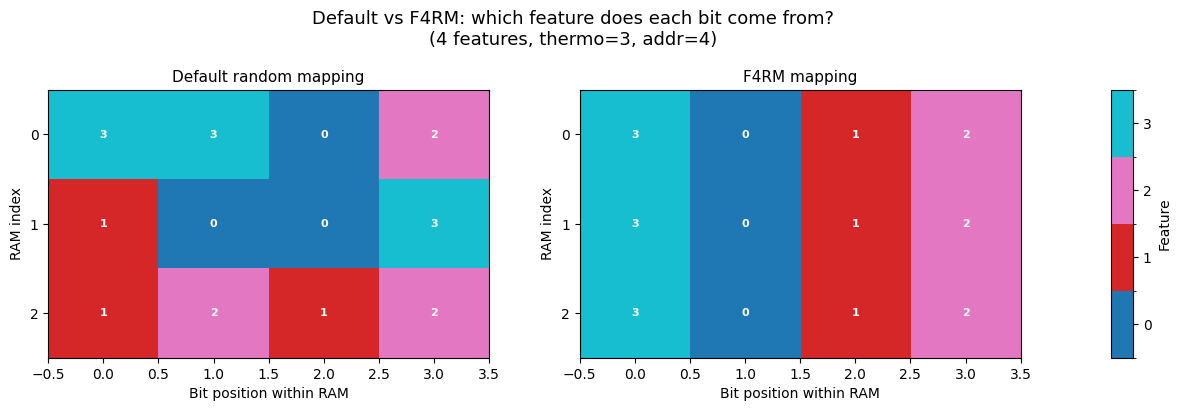

In [22]:
# Visual comparison: colored grid showing feature origin of each bit
def plot_mapping_grid(mapping, n_features, thermo_size, addr_size, ax, title):
    """Plot a colored grid showing feature origin of each bit in each RAM."""
    n_rams = len(mapping)
    grid = np.full((n_rams, addr_size), -1, dtype=int)
    for r, ram_bits in enumerate(mapping):
        for j, bit in enumerate(ram_bits):
            grid[r, j] = bit_to_feature(bit, thermo_size)

    cmap = plt.colormaps.get_cmap('tab10').resampled(n_features)
    bounds = np.arange(-0.5, n_features + 0.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    im = ax.imshow(grid, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
    ax.set_xlabel('Bit position within RAM')
    ax.set_ylabel('RAM index')
    ax.set_yticks(range(n_rams))
    ax.set_title(title, fontsize=11)

    for r in range(n_rams):
        for j in range(len(mapping[r])):
            f = grid[r, j]
            if f >= 0:
                ax.text(j, r, str(f), ha='center', va='center',
                        fontsize=8, fontweight='bold', color='white')
    return im

fig, (ax_def, ax_f4rm, ax_cbar) = plt.subplots(1, 3, figsize=(14, 4),
    gridspec_kw={'width_ratios': [1, 1, 0.05]})

plot_mapping_grid(default_map, ex_nf, ex_ts, ex_as, ax_def, 'Default random mapping')
im = plot_mapping_grid(f4rm_map, ex_nf, ex_ts, ex_as, ax_f4rm, 'F4RM mapping')
fig.colorbar(im, cax=ax_cbar, ticks=range(ex_nf), label='Feature')

fig.suptitle(f'Default vs F4RM: which feature does each bit come from?\n'
             f'({ex_nf} features, thermo={ex_ts}, addr={ex_as})', fontsize=13)
fig.subplots_adjust(top=0.78, wspace=0.3)
plt.show()

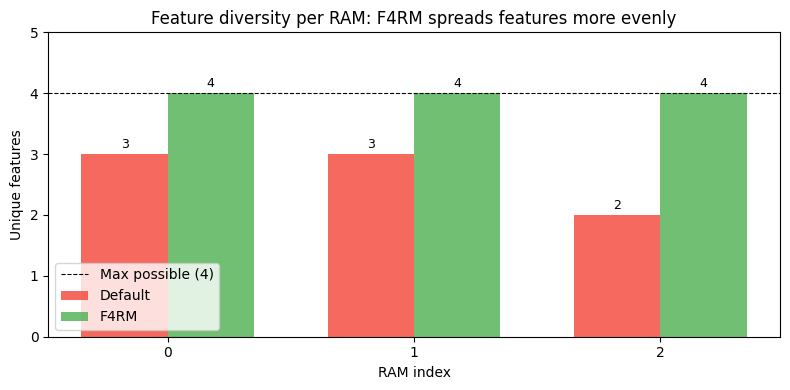

In [23]:
# Feature diversity per RAM: how many unique features does each RAM see?
def unique_features_per_ram(mapping, thermo_size):
    return [len(set(bit_to_feature(b, thermo_size) for b in ram)) for ram in mapping]

default_diversity = unique_features_per_ram(default_map, ex_ts)
f4rm_diversity = unique_features_per_ram(f4rm_map, ex_ts)

x = np.arange(len(default_map))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, default_diversity, width, label='Default', color='#F44336', alpha=0.8)
ax.bar(x + width/2, f4rm_diversity, width, label='F4RM', color='#4CAF50', alpha=0.8)
ax.set_xlabel('RAM index')
ax.set_ylabel('Unique features')
ax.set_title('Feature diversity per RAM: F4RM spreads features more evenly')
ax.set_xticks(x)
ax.set_ylim(0, ex_nf + 1)
ax.axhline(y=ex_nf, color='black', linestyle='--', linewidth=0.8,
           label=f'Max possible ({ex_nf})')
ax.legend()

for i, (d, f) in enumerate(zip(default_diversity, f4rm_diversity)):
    ax.text(i - width/2, d + 0.1, str(d), ha='center', fontsize=9)
    ax.text(i + width/2, f + 0.1, str(f), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 Real Scale: EEG Eye State (14 Features)

The EEG Eye State dataset has 14 features. At the default address rule (`addr = min(2n, floor(log2(m)))`), this gives `addr = 13` — a ratio of ~0.93. Here we use `addr=28` (ratio 2.0) to match the visualization in **Figure 1 of the paper**: at this ratio, every RAM is guaranteed to see every feature at least once, and F4RM produces the striking vertical-stripe heatmap pattern (each column of the RAM-by-bit grid corresponds to the same feature across all RAMs), versus the chaotic default pattern.

EEG: 14 features x 32 thermo = 448 bits
Address size: 28, RAMs: 16
Bits per feature per RAM (ideal): 2.0


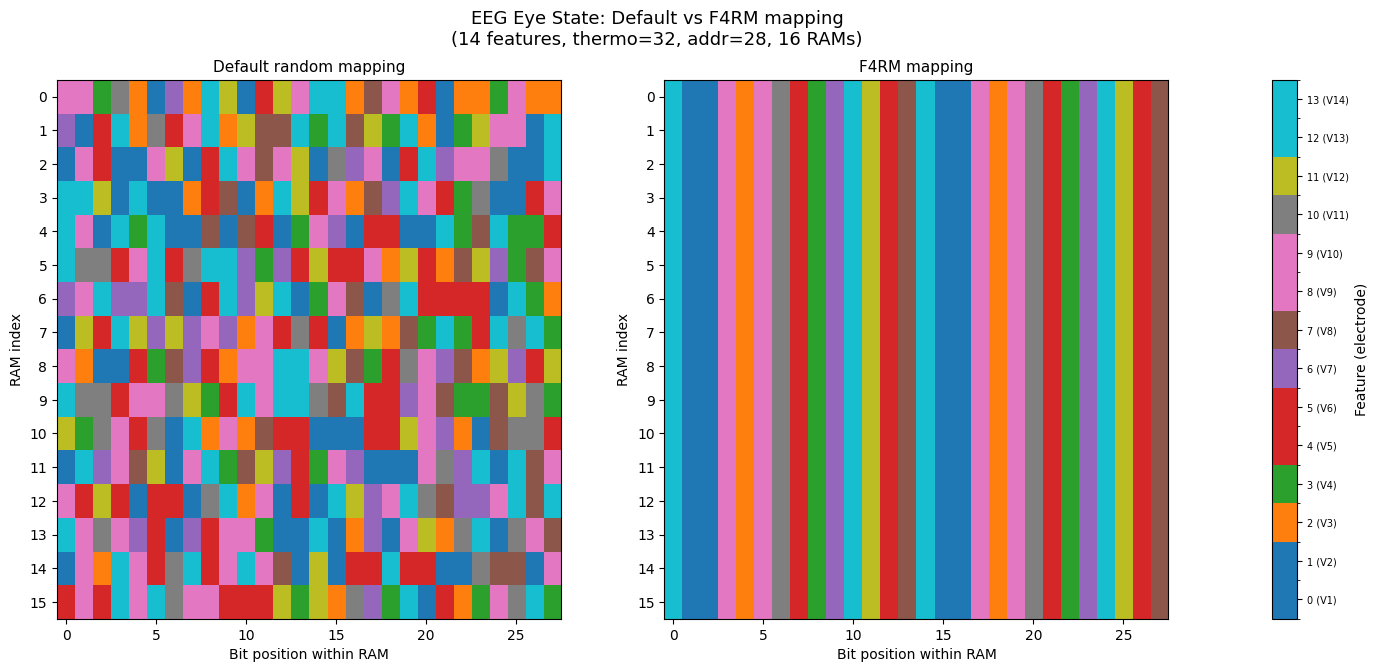


Unique features per RAM:
  Default: min=11, max=14, mean=12.6
  F4RM:    min=14, max=14, mean=14.0


In [24]:
# F4RM at real scale: EEG Eye State (14 features, thermo=32, addr=28)
eeg_nf, eeg_ts, eeg_as = 14, 32, 28

eeg_default = generate_default_random_mapping(eeg_nf, eeg_ts, eeg_as, seed=SEED)
eeg_f4rm = generate_f4rm_mapping(eeg_nf, eeg_ts, eeg_as, seed=SEED)

n_eeg_rams = len(eeg_f4rm)
print(f"EEG: {eeg_nf} features x {eeg_ts} thermo = {eeg_nf * eeg_ts} bits")
print(f"Address size: {eeg_as}, RAMs: {n_eeg_rams}")
print(f"Bits per feature per RAM (ideal): {eeg_as / eeg_nf:.1f}")

fig, (ax_def, ax_f4rm, ax_cbar) = plt.subplots(1, 3, figsize=(16, 7),
    gridspec_kw={'width_ratios': [1, 1, 0.05]})

plot_mapping_grid(eeg_default, eeg_nf, eeg_ts, eeg_as, ax_def, 'Default random mapping')
im = plot_mapping_grid(eeg_f4rm, eeg_nf, eeg_ts, eeg_as, ax_f4rm, 'F4RM mapping')

# Remove text annotations at this scale
for ax in [ax_def, ax_f4rm]:
    for txt in ax.texts:
        txt.remove()

cbar = fig.colorbar(im, cax=ax_cbar, ticks=range(eeg_nf), label='Feature (electrode)')
cbar.ax.set_yticklabels([f'{i} ({n})' for i, n in enumerate(eeg_feature_names)], fontsize=7)

fig.suptitle(f'EEG Eye State: Default vs F4RM mapping\n'
             f'({eeg_nf} features, thermo={eeg_ts}, addr={eeg_as}, {n_eeg_rams} RAMs)',
             fontsize=13)
fig.subplots_adjust(top=0.88, wspace=0.3)
plt.show()

# Summary stats
def_div = unique_features_per_ram(eeg_default, eeg_ts)
f4rm_div = unique_features_per_ram(eeg_f4rm, eeg_ts)
print(f"\nUnique features per RAM:")
print(f"  Default: min={min(def_div)}, max={max(def_div)}, mean={np.mean(def_div):.1f}")
print(f"  F4RM:    min={min(f4rm_div)}, max={max(f4rm_div)}, mean={np.mean(f4rm_div):.1f}")

### 4.3 When F4RM Does Not Help: MNIST (784 Features)

With 784 features and `addr_size=28`, the ratio is 28/784 ≈ 0.036. Each RAM reads 28 bits from a pool of 784 features, so same-feature collisions are rare by chance. F4RM cannot improve on what random sampling already delivers. This is the **scope-condition regime** discussed in paper Section 2.4 / 7.1: F4RM's benefit requires `a/n` large enough for frequent collisions, and image datasets at standard address sizes fall well below that threshold.

MNIST: 784 features x 3 thermo = 2352 bits
Address size: 28, RAMs: 84
Ratio addr/features: 0.036


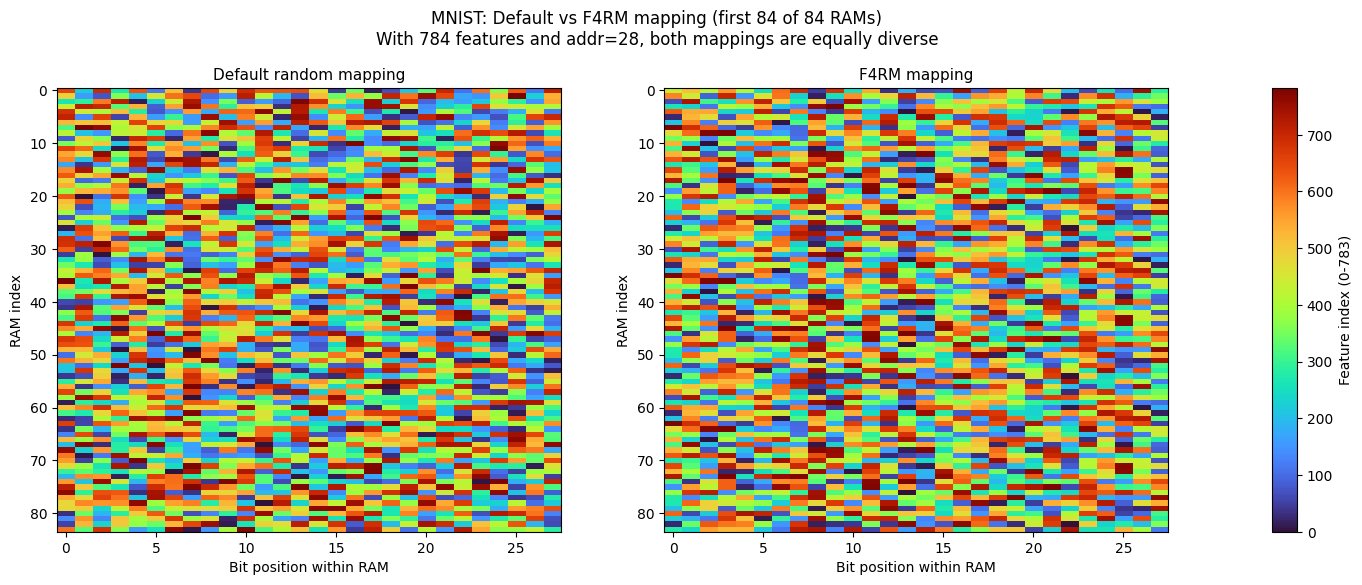


Unique features per RAM:
  Default: min=25, max=28, mean=27.6
  F4RM:    min=28, max=28, mean=28.0


In [25]:
# F4RM vs default on MNIST: 784 features, thermo=3, addr=28
mnist_nf, mnist_ts, mnist_as = 784, 3, 28

mnist_default = generate_default_random_mapping(mnist_nf, mnist_ts, mnist_as, seed=SEED)
mnist_f4rm = generate_f4rm_mapping(mnist_nf, mnist_ts, mnist_as, seed=SEED)

n_mnist_rams = len(mnist_f4rm)
print(f"MNIST: {mnist_nf} features x {mnist_ts} thermo = {mnist_nf * mnist_ts} bits")
print(f"Address size: {mnist_as}, RAMs: {n_mnist_rams}")
print(f"Ratio addr/features: {mnist_as / mnist_nf:.3f}")

# Show first 20 RAMs
zoom = 84

def plot_mapping_grid_continuous(mapping, n_features, thermo_size, addr_size, ax, title, n_rows=None):
    if n_rows is None:
        n_rows = len(mapping)
    grid = np.full((n_rows, addr_size), np.nan)
    for r in range(n_rows):
        for j, bit in enumerate(mapping[r]):
            grid[r, j] = bit_to_feature(bit, thermo_size)
    im = ax.imshow(grid, cmap='turbo', aspect='auto', interpolation='nearest',
                   norm=Normalize(vmin=0, vmax=n_features-1))
    ax.set_xlabel('Bit position within RAM')
    ax.set_ylabel('RAM index')
    ax.set_title(title, fontsize=11)
    return im

fig, (ax_def, ax_f4rm, ax_cbar) = plt.subplots(1, 3, figsize=(16, 6),
    gridspec_kw={'width_ratios': [1, 1, 0.05]})

plot_mapping_grid_continuous(mnist_default, mnist_nf, mnist_ts, mnist_as, ax_def,
                            'Default random mapping', n_rows=zoom)
im = plot_mapping_grid_continuous(mnist_f4rm, mnist_nf, mnist_ts, mnist_as, ax_f4rm,
                                 'F4RM mapping', n_rows=zoom)

fig.colorbar(im, cax=ax_cbar, label='Feature index (0-783)')

fig.suptitle(f'MNIST: Default vs F4RM mapping (first {zoom} of {n_mnist_rams} RAMs)\n'
             f'With {mnist_nf} features and addr={mnist_as}, both mappings are equally diverse',
             fontsize=12)
fig.subplots_adjust(top=0.85, wspace=0.3)
plt.show()

# Diversity comparison
def_div_m = unique_features_per_ram(mnist_default, mnist_ts)
f4rm_div_m = unique_features_per_ram(mnist_f4rm, mnist_ts)
print(f"\nUnique features per RAM:")
print(f"  Default: min={min(def_div_m)}, max={max(def_div_m)}, mean={np.mean(def_div_m):.1f}")
print(f"  F4RM:    min={min(f4rm_div_m)}, max={max(f4rm_div_m)}, mean={np.mean(f4rm_div_m):.1f}")

### Summary

F4RM guarantees maximum feature diversity per RAM. Its benefit depends on the ratio `addr_size / n_features`:

| Ratio | Example | F4RM effect |
|-------|---------|-------------|
| >> 1 | EEG (addr=28, n=14 → 2.0) | Large: prevents feature collision, every RAM sees every feature |
| ~ 1 | Glass (addr=9, n=9 → 1.0) | Moderate: ensures each RAM sees distinct features |
| << 1 | MNIST (addr=28, n=784 → 0.04) | None: random mapping is already diverse by chance |

The default address rule of the paper (`a = min(2n, floor(log2(m)))`) places `a/n = 2` whenever the sample-size cap does not bind — i.e., it deliberately places both Random and F4RM in a regime where any mapping-level difference is measurable. This rule is applied identically to every method so that the comparison is not confounded by hyperparameter selection.

## 5. Why F4RM Works

The argument is combinatorial, not empirical. It relies on one structural property of thermometer-encoded bits: the `t` bits of a single feature take only `t+1` distinct values instead of the `2^t` that the RAM's address space allocates for them.

### Two costs of same-feature collisions

When random mapping places `c` bits from the same feature into the same RAM, two costs appear simultaneously (see paper Section 2.2):

1. **Feature-coverage loss.** A RAM receiving two bits from feature `f` forces another RAM to receive one fewer bit of `f`; in the limit, some RAM is blind to `f` entirely.
2. **Effective-capacity loss.** Those `c` bits jointly produce only `c+1` patterns instead of `2^c`, shrinking the RAM's usable address space to a fraction `(c+1)/2^c` of what it would be with independent bits — down to 3/4 at `c=2`, 1/2 at `c=3`, and so on.

Both costs scale with the frequency of same-feature collisions, which is governed by the ratio `a/n`. When `a/n << 1` collisions are rare by chance; when `a/n >= 1` the pigeonhole principle guarantees at least one collision per RAM.

### Collision probability (empirical check)

The cell below computes the probability that a RAM of size `a` drawn uniformly at random from `n · t` bits contains **no** two bits from the same feature, compared against an empirical draw. F4RM pins this probability to 1 whenever `a <= n`, and for `a > n` forces the collisions that must happen to be spread as evenly as possible across RAMs.

### Why F4RM only touches one dimension

F4RM controls *which feature* contributes to each RAM position — it does not touch *which thermometer level*. The stochastic level-selection that random mapping relies on is preserved inside each RAM. F4RM restricts the mapping only along the axis where unrestricted randomness is actively harmful.

  ratio=0.25 (addr=  4): P(collision) = 1.000
  ratio=0.50 (addr=  7): P(collision) = 1.000
  ratio=0.75 (addr= 10): P(collision) = 1.000
  ratio=1.00 (addr= 14): P(collision) = 1.000
  ratio=1.25 (addr= 18): P(collision) = 1.000
  ratio=1.50 (addr= 21): P(collision) = 1.000
  ratio=2.00 (addr= 28): P(collision) = 1.000
  ratio=2.50 (addr= 35): P(collision) = 1.000
  ratio=3.00 (addr= 42): P(collision) = 1.000


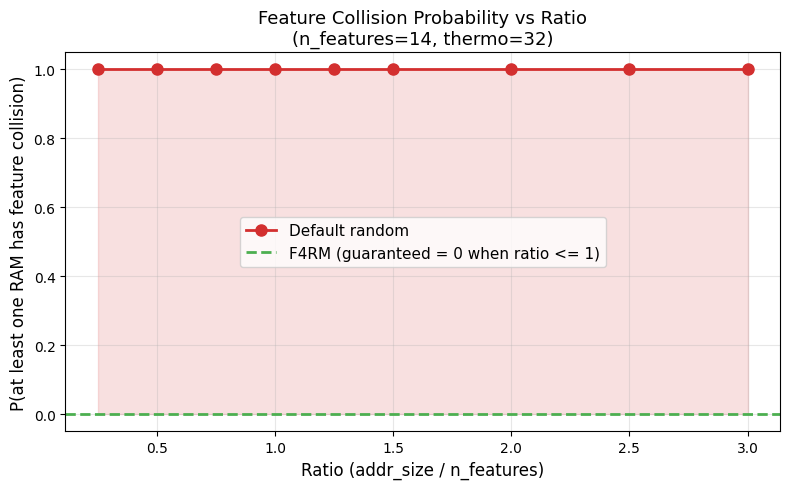

In [14]:
# Collision probability: analytical vs empirical
def collision_prob_empirical(n_features, thermo_size, addr_size, n_trials=1000):
    """Empirical probability that at least one RAM has two bits from the same feature."""
    collisions = 0
    for seed in range(n_trials):
        mapping = generate_default_random_mapping(n_features, thermo_size, addr_size, seed=seed)
        for ram in mapping:
            feats = [bit_to_feature(b, thermo_size) for b in ram]
            if len(feats) != len(set(feats)):
                collisions += 1
                break
    return collisions / n_trials

# Sweep ratio for a fixed n_features=14, thermo=32
ratios = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
n_feat_test = 14
ts_test = 32

probs = []
for ratio in ratios:
    addr = max(2, round(ratio * n_feat_test))
    p = collision_prob_empirical(n_feat_test, ts_test, addr, n_trials=500)
    probs.append(p)
    print(f"  ratio={ratio:.2f} (addr={addr:3d}): P(collision) = {p:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ratios, probs, 'o-', color='#D32F2F', linewidth=2, markersize=8, label='Default random')
ax.axhline(y=0, color='#4CAF50', linewidth=2, linestyle='--', label='F4RM (guaranteed = 0 when ratio <= 1)')
ax.fill_between(ratios, probs, alpha=0.15, color='#D32F2F')
ax.set_xlabel('Ratio (addr_size / n_features)', fontsize=12)
ax.set_ylabel('P(at least one RAM has feature collision)', fontsize=12)
ax.set_title(f'Feature Collision Probability vs Ratio\n(n_features={n_feat_test}, thermo={ts_test})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 6. Mapping Validation

Verify that `generate_f4rm_mapping` produces valid constrained mappings: all bits appear exactly once, and the per-feature-per-RAM bit count is minimized.

In [17]:
# === Validate F4RM mapping ===

# Test with EEG config: 14 features, thermo=32, addr=28 (addr > n_features)
n_feat_v, ts_v, addr_v = 14, 32, 28
total_bits_v = n_feat_v * ts_v
n_rams_v = math.ceil(total_bits_v / addr_v)
max_per_feature = math.ceil(addr_v / n_feat_v)

print(f"EEG config: {n_feat_v} features, thermo={ts_v}, addr={addr_v}")
print(f"Total bits: {total_bits_v}, RAMs: {n_rams_v}, max bits/feature/RAM: {max_per_feature}")

all_valid = True
max_violations = []
for seed in range(100):
    mapping = generate_f4rm_mapping(n_feat_v, ts_v, addr_v, seed=seed)
    all_bits = sorted([b for ram in mapping for b in ram])
    assert all_bits == list(range(total_bits_v)), f"Seed {seed}: not a valid permutation"
    worst = 0
    for ram in mapping:
        feat_counts = {}
        for b in ram:
            f = b // ts_v
            feat_counts[f] = feat_counts.get(f, 0) + 1
        worst = max(worst, max(feat_counts.values()))
    max_violations.append(worst)

print(f"\n100 mappings tested:")
print(f"  All valid permutations: YES")
print(f"  Max bits/feature/RAM across all: {max(max_violations)}")
print(f"  Theoretical minimum: {max_per_feature}")
print(f"  All achieve minimum: {all(v == max_per_feature for v in max_violations)}")

# Determinism and diversity
m1 = generate_f4rm_mapping(n_feat_v, ts_v, addr_v, seed=0)
m2 = generate_f4rm_mapping(n_feat_v, ts_v, addr_v, seed=1)
m_same = generate_f4rm_mapping(n_feat_v, ts_v, addr_v, seed=0)
print(f"  Seed 0 != Seed 1: {m1 != m2}")
print(f"  Seed 0 == Seed 0 (deterministic): {m1 == m_same}")

# Strict constraint case: addr <= n_features
print(f"\nVehicle config: 18 features, thermo=32, addr=14 (addr <= n_features)")
n_feat_v2, ts_v2, addr_v2 = 18, 32, 14
for seed in range(100):
    mapping = generate_f4rm_mapping(n_feat_v2, ts_v2, addr_v2, seed=seed)
    all_bits = sorted([b for ram in mapping for b in ram])
    assert all_bits == list(range(n_feat_v2 * ts_v2))
    for ram in mapping:
        feat_counts = {}
        for b in ram:
            f = b // ts_v2
            feat_counts[f] = feat_counts.get(f, 0) + 1
        assert max(feat_counts.values()) == 1, f"Constraint violated"
print(f"  100 mappings: all valid, strict constraint satisfied (max 1 bit/feature/RAM)")

EEG config: 14 features, thermo=32, addr=28
Total bits: 448, RAMs: 16, max bits/feature/RAM: 2

100 mappings tested:
  All valid permutations: YES
  Max bits/feature/RAM across all: 2
  Theoretical minimum: 2
  All achieve minimum: True
  Seed 0 != Seed 1: True
  Seed 0 == Seed 0 (deterministic): True

Vehicle config: 18 features, thermo=32, addr=14 (addr <= n_features)
  100 mappings: all valid, strict constraint satisfied (max 1 bit/feature/RAM)


## 7. Hyperparameter Landscape: Address Size vs Thermometer Size

WiSARD's two primary hyperparameters are **address size** `a` (bits per RAM, controlling the granularity of the lookup) and **thermometer size** `t` (encoding resolution per feature). Their interaction sets the trade-off between under-fitting (`a` too small to be discriminative) and memorizing (`a` so large that `2^a > m` and most addresses stay unreachable). The heatmap below, computed on EEG Eye State, shows the accuracy landscape over the `(a, t)` grid — a sanity check for the default address rule and the `t=8` choice fixed for all datasets in Experiment 2.

In [25]:
# === addressSize x thermoSize heatmap on EEG Eye State ===
HEATMAP_THERMO_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
HEATMAP_ADDRESS_SIZES = [2, 4, 8, 16, 32, 64, 128, 256]

X_eeg, y_eeg = DATASETS['EEG Eye State'][0], DATASETS['EEG Eye State'][1]
n_hm_feat = X_eeg.shape[1]

X_hm_train, X_hm_test, y_hm_train, y_hm_test = train_test_split(
    X_eeg, y_eeg, test_size=0.2, random_state=SEED)

scaler = MinMaxScaler()
X_hm_train_s = scaler.fit_transform(X_hm_train)
X_hm_test_s = scaler.transform(X_hm_test)

acc_matrix = np.zeros((len(HEATMAP_ADDRESS_SIZES), len(HEATMAP_THERMO_SIZES)))

total_start = time.time()
for j, ts in enumerate(HEATMAP_THERMO_SIZES):
    th = create_thermometer(ts, X_hm_train_s)
    Xtr = binarize_dataset(X_hm_train_s, th)
    Xte = binarize_dataset(X_hm_test_s, th)

    for i, addr in enumerate(HEATMAP_ADDRESS_SIZES):
        w = wp.Wisard(addr)
        w.train(wp.DataSet(Xtr, y_hm_train.tolist()))
        preds = w.classify(wp.DataSet(Xte))
        acc_matrix[i, j] = compute_accuracy(preds, y_hm_test)

    print(f"Thermo {ts} done in {time.time() - total_start:.1f}s")

print(f"Done in {time.time() - total_start:.1f}s")

Thermo 4 done in 1.4s
Thermo 8 done in 1.8s
Thermo 16 done in 2.5s
Thermo 32 done in 4.0s
Thermo 64 done in 6.8s
Thermo 128 done in 12.3s
Thermo 256 done in 23.7s
Thermo 512 done in 48.7s
Thermo 1024 done in 101.2s
Thermo 2048 done in 235.2s
Thermo 4096 done in 518.3s
Thermo 8192 done in 1088.8s
Thermo 16384 done in 2286.7s
Done in 2286.7s


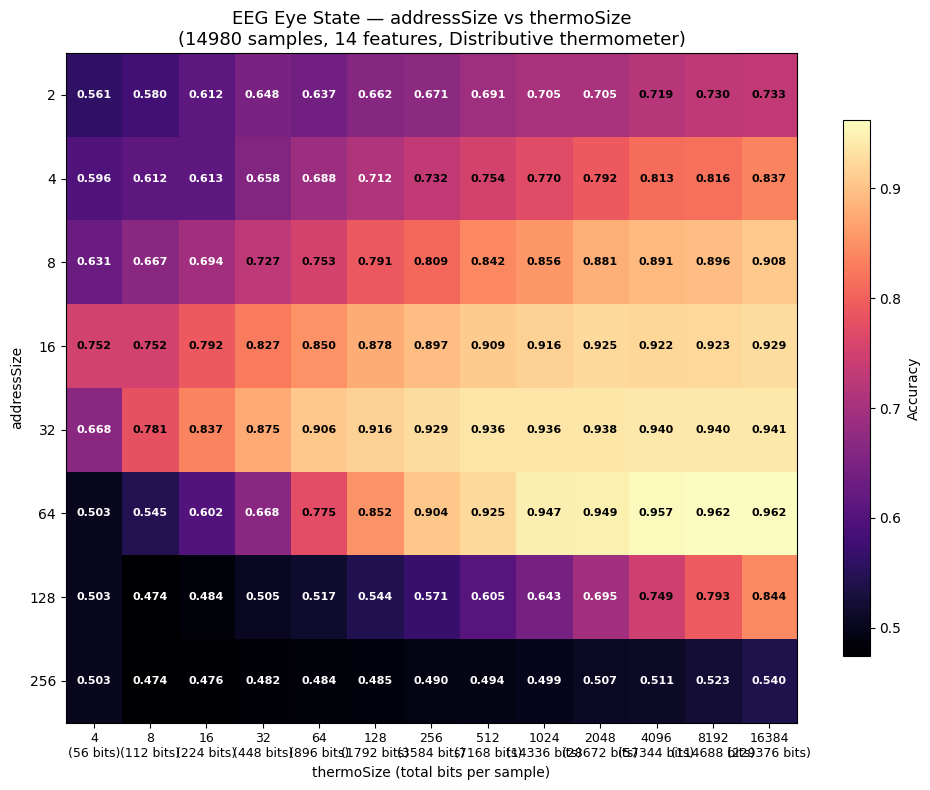

Best: addressSize=64, thermoSize=16384 -> 0.9623


In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
x_labels = [f'{ts}\n({n_hm_feat*ts} bits)' for ts in HEATMAP_THERMO_SIZES]
y_labels = [str(a) for a in HEATMAP_ADDRESS_SIZES]

im = ax.imshow(acc_matrix, cmap='magma', aspect='auto')
for i in range(len(HEATMAP_ADDRESS_SIZES)):
    for j in range(len(HEATMAP_THERMO_SIZES)):
        val = acc_matrix[i, j]
        color = 'white' if val < (acc_matrix.min() + acc_matrix.max()) / 2 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=8, color=color, fontweight='bold')

ax.set_xticks(range(len(HEATMAP_THERMO_SIZES)))
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_yticks(range(len(HEATMAP_ADDRESS_SIZES)))
ax.set_yticklabels(y_labels)
ax.set_xlabel('thermoSize (total bits per sample)')
ax.set_ylabel('addressSize')
plt.colorbar(im, ax=ax, label='Accuracy', shrink=0.8)
ax.set_title(f'EEG Eye State — addressSize vs thermoSize\n'
             f'({X_eeg.shape[0]} samples, {n_hm_feat} features, Distributive thermometer)',
             fontsize=13)
plt.tight_layout()
plt.show()

best = np.unravel_index(acc_matrix.argmax(), acc_matrix.shape)
print(f"Best: addressSize={HEATMAP_ADDRESS_SIZES[best[0]]}, "
      f"thermoSize={HEATMAP_THERMO_SIZES[best[1]]} -> {acc_matrix.max():.4f}")

## 8. Experiment 1: Random vs F4RM Across 22 Datasets — Best-Config Sanity Check

**Role in the paper.** This is the exploratory grid search. It does **not** correspond to the paper's main table (that is Experiment 2 below, under Section 9/10); instead, it maps out how F4RM's benefit varies across the `(addr, thermo)` landscape on all 22 datasets and exposes how strongly that benefit depends on `a/n`. The paper's main evaluation deliberately fixes hyperparameters per the default rule to avoid selection effects, so the "best-per-dataset" numbers reported below are for analytical context, not for the headline table.

### Protocol

- **22 datasets** (all loaded datasets, including Cardiotocography).
- **Grid:** `thermo ∈ {8, 16, 32, 64}` and `addr` targeting ratios `{0.25, 0.33, 0.5, 1.0, 1.5, 2.0, 3.0}` relative to `n_features`. Deduplicated by `(addr, thermo)`.
- **N_RUNS = 100** paired stratified 80/20 splits per `(dataset, addr, thermo)` cell, shared between Random and F4RM.
- **Preprocessing:** MinMaxScaler + distributive thermometer, both fit on the training fold only.
- **Statistics:** paired Wilcoxon signed-rank test, Bonferroni correction at `α = 0.05 / 22 ≈ 0.0023`, Cohen's d, 95% CI.

Results are reported at the `(addr, thermo)` combination that maximizes F4RM mean accuracy per dataset. This is what "best-config sanity check" means: the grid answers *what can F4RM achieve with tuning*, not *what does F4RM achieve at the principled default*. The principled-default evaluation is Experiment 2.

In [27]:
# === Configuration grid generation ===
EXP1_CONFIGS = {}

print(f"{'Dataset':25s} {'n_feat':>6s} | {'Configs':>8s}")
print(f"{'-'*45}")

for name in sorted(DATASETS.keys(), key=lambda n: DATASETS[n][2]):
    X_d, y_d, n_feat = DATASETS[name]
    configs = []
    for thermo in THERMO_OPTIONS:
        total_bits = n_feat * thermo
        for target_ratio in RATIO_OPTIONS:
            addr = max(2, round(target_ratio * n_feat))
            n_rams = math.ceil(total_bits / addr)
            if n_rams < 2:
                continue
            ratio = addr / n_feat
            configs.append((addr, thermo, ratio, n_rams))
    # Deduplicate by (addr, thermo)
    seen = set()
    unique_configs = []
    for c in configs:
        key = (c[0], c[1])
        if key not in seen:
            seen.add(key)
            unique_configs.append(c)
    EXP1_CONFIGS[name] = unique_configs
    print(f"{name:25s} {n_feat:>6d} | {len(unique_configs):>8d} configs")

total_configs = sum(len(c) for c in EXP1_CONFIGS.values())
print(f"\nTotal configs across all datasets: {total_configs}")

Dataset                   n_feat |  Configs
---------------------------------------------
Haberman                       3 |       20 configs
Iris                           4 |       20 configs
Balance Scale                  4 |       20 configs
Banknote                       4 |       20 configs
Ecoli                          7 |       24 configs
Seeds                          7 |       24 configs
Pima Diabetes                  8 |       28 configs
Yeast                          8 |       28 configs
Glass                          9 |       28 configs
Magic Gamma                   10 |       28 configs
Wine                          13 |       28 configs
EEG Eye State                 14 |       28 configs
Pendigits                     16 |       28 configs
Letter Recognition            16 |       28 configs
Vehicle                       18 |       28 configs
Segment                       19 |       28 configs
Breast Cancer                 30 |       28 configs
Steel Plates              

In [28]:
# === Experiment 1: Multi-Config Paired Evaluation ===
EXP1_RESULTS = {}  # {(ds_name, addr, thermo): {random_accs, f4rm_accs, ...}}
total_start = time.time()

ds_order = sorted(DATASETS.keys(),
                  key=lambda n: DATASETS[n][0].shape[0] * DATASETS[n][2])

for ds_name in ds_order:
    X_ds, y_ds, n_feat = DATASETS[ds_name]
    configs = EXP1_CONFIGS[ds_name]
    classes = sorted(set(y_ds.astype(str)))

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {n_feat} feat, {len(configs)} configs")
    print(f"{'='*70}")

    for ci, (addr, ts, ratio, n_rams) in enumerate(configs):
        config_start = time.time()
        random_accs = []
        f4rm_accs = []

        for run in range(N_RUNS):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_ds, y_ds, test_size=0.2, stratify=y_ds, random_state=run)
            scaler = MinMaxScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            thermo_obj = create_thermometer(ts, X_tr_s)
            X_tr_bin = binarize_dataset(X_tr_s, thermo_obj)
            X_te_bin = binarize_dataset(X_te_s, thermo_obj)
            train_ds = wp.DataSet(X_tr_bin, y_tr.astype(str).tolist())
            test_ds = wp.DataSet(X_te_bin)

            # Random mapping
            w_rand = wp.Wisard(addr)
            w_rand.train(train_ds)
            random_accs.append(compute_accuracy(w_rand.classify(test_ds), y_te.astype(str)))

            # F4RM mapping
            mapping = generate_f4rm_mapping(n_feat, ts, addr, seed=run)
            mapping_dict = {cls: mapping for cls in classes}
            w_f4rm = wp.Wisard(addr, mapping=mapping_dict)
            w_f4rm.train(train_ds)
            f4rm_accs.append(compute_accuracy(w_f4rm.classify(test_ds), y_te.astype(str)))

        elapsed_cfg = time.time() - config_start
        rand_mean = np.mean(random_accs)
        f4rm_mean = np.mean(f4rm_accs)
        delta = f4rm_mean - rand_mean

        EXP1_RESULTS[(ds_name, addr, ts)] = {
            'random_accs': np.array(random_accs),
            'f4rm_accs': np.array(f4rm_accs),
            'n_runs': len(random_accs),
            'ratio': ratio, 'n_rams': n_rams,
            'addr': addr, 'thermo': ts
        }

        print(f"  [{ci+1}/{len(configs)}] addr={addr:>4d} thermo={ts:>3d} ratio={ratio:.2f} "
              f"rand={rand_mean:.4f} f4rm={f4rm_mean:.4f} delta={delta:+.4f} ({elapsed_cfg:.0f}s)")

total_elapsed = time.time() - total_start
print(f"\nAll done! Total time: {total_elapsed/60:.1f} min")


Iris: 150 samples, 4 feat, 20 configs
  [1/20] addr=   2 thermo=  8 ratio=0.50 rand=0.9433 f4rm=0.9447 delta=+0.0013 (0s)
  [2/20] addr=   4 thermo=  8 ratio=1.00 rand=0.9443 f4rm=0.9527 delta=+0.0083 (0s)
  [3/20] addr=   6 thermo=  8 ratio=1.50 rand=0.9473 f4rm=0.9517 delta=+0.0043 (0s)
  [4/20] addr=   8 thermo=  8 ratio=2.00 rand=0.9497 f4rm=0.9520 delta=+0.0023 (0s)
  [5/20] addr=  12 thermo=  8 ratio=3.00 rand=0.9400 f4rm=0.9427 delta=+0.0027 (0s)
  [6/20] addr=   2 thermo= 16 ratio=0.50 rand=0.9303 f4rm=0.9317 delta=+0.0013 (0s)
  [7/20] addr=   4 thermo= 16 ratio=1.00 rand=0.9437 f4rm=0.9467 delta=+0.0030 (0s)
  [8/20] addr=   6 thermo= 16 ratio=1.50 rand=0.9427 f4rm=0.9487 delta=+0.0060 (0s)
  [9/20] addr=   8 thermo= 16 ratio=2.00 rand=0.9497 f4rm=0.9527 delta=+0.0030 (0s)
  [10/20] addr=  12 thermo= 16 ratio=3.00 rand=0.9447 f4rm=0.9523 delta=+0.0077 (0s)
  [11/20] addr=   2 thermo= 32 ratio=0.50 rand=0.9490 f4rm=0.9467 delta=-0.0023 (0s)
  [12/20] addr=   4 thermo= 32 rati

In [29]:
# === Experiment 1: Results Table ===
print(f"\n{'='*130}")
print(f"BEST CONFIG PER DATASET (by F4RM accuracy, {N_RUNS} runs)")
print(f"{'='*130}")
print(f"{'Dataset':25s} {'n':>4s} {'addr':>5s} {'thr':>4s} {'ratio':>6s} "
      f"{'Random':>12s} {'F4RM':>12s} {'Delta':>8s} {'95% CI':>16s} {'p-value':>10s} {'d':>6s} {'Sig':>5s}")
print(f"{'-'*130}")

exp1_summary = {}
exp1_best_key = {}

for ds_name in sorted(DATASETS.keys(), key=lambda n: DATASETS[n][2]):
    best_key, best_f4rm = None, -1
    for (dn, addr, ts), r in EXP1_RESULTS.items():
        if dn == ds_name and np.mean(r['f4rm_accs']) > best_f4rm:
            best_f4rm = np.mean(r['f4rm_accs'])
            best_key = (dn, addr, ts)
    if best_key is None:
        continue

    r = EXP1_RESULTS[best_key]
    n_feat = DATASETS[ds_name][2]
    deltas = r['f4rm_accs'] - r['random_accs']
    mean_delta = np.mean(deltas)
    ci_half = 1.96 * np.std(deltas) / np.sqrt(len(deltas))

    try:
        _, p_val = wilcoxon(r['f4rm_accs'], r['random_accs'])
    except:
        p_val = 1.0

    pooled_std = np.sqrt((np.std(r['random_accs'])**2 + np.std(r['f4rm_accs'])**2) / 2)
    d = mean_delta / pooled_std if pooled_std > 0 else 0

    if p_val < BONFERRONI_ALPHA and mean_delta > 0:
        sig = '+++'
    elif p_val < BONFERRONI_ALPHA and mean_delta < 0:
        sig = '---'
    else:
        sig = 'n.s.'

    delta_pp = mean_delta * 100
    ci_lo, ci_hi = (mean_delta - ci_half) * 100, (mean_delta + ci_half) * 100

    print(f"{ds_name:25s} {n_feat:>4d} {r['addr']:>5d} {r['thermo']:>4d} {r['ratio']:>6.2f} "
          f"{np.mean(r['random_accs']):.4f}+/-{np.std(r['random_accs']):.3f} "
          f"{np.mean(r['f4rm_accs']):.4f}+/-{np.std(r['f4rm_accs']):.3f} "
          f"{delta_pp:>+7.2f}pp [{ci_lo:>+6.2f},{ci_hi:>+6.2f}] "
          f"{p_val:>10.2e} {d:>6.3f} {sig:>5s}")

    exp1_summary[ds_name] = {
        'n_feat': n_feat, 'addr': r['addr'], 'thermo': r['thermo'],
        'ratio': r['ratio'], 'delta_pp': delta_pp, 'p': p_val, 'd': d, 'sig': sig,
        'rand_mean': np.mean(r['random_accs']), 'f4rm_mean': best_f4rm,
    }
    exp1_best_key[ds_name] = best_key

n_sig_pos = sum(1 for s in exp1_summary.values() if s['delta_pp'] > 0 and s['p'] < BONFERRONI_ALPHA)
n_sig_neg = sum(1 for s in exp1_summary.values() if s['delta_pp'] < 0 and s['p'] < BONFERRONI_ALPHA)
n_neutral = len(exp1_summary) - n_sig_pos - n_sig_neg
print(f"\nSignificant gains: {n_sig_pos}, losses: {n_sig_neg}, neutral: {n_neutral}")


BEST CONFIG PER DATASET (by F4RM accuracy, 100 runs)
Dataset                      n  addr  thr  ratio       Random         F4RM    Delta           95% CI    p-value      d   Sig
----------------------------------------------------------------------------------------------------------------------------------
Haberman                     3     2   16   0.67 0.7392+/-0.035 0.7394+/-0.041   +0.02pp [ -0.74, +0.77]   7.42e-01  0.004  n.s.
Iris                         4     4   32   1.00 0.9537+/-0.039 0.9590+/-0.033   +0.53pp [ +0.01, +1.05]   5.45e-02  0.147  n.s.
Balance Scale                4     4   64   1.00 0.8550+/-0.021 0.8613+/-0.024   +0.63pp [ +0.06, +1.21]   3.07e-02  0.284  n.s.
Banknote                     4     8   64   2.00 0.9979+/-0.003 0.9988+/-0.003   +0.09pp [ +0.03, +0.15]   2.67e-03  0.322  n.s.
Ecoli                        7    10   64   1.43 0.8613+/-0.034 0.8647+/-0.033   +0.34pp [ -0.24, +0.92]   5.30e-01  0.101  n.s.
Seeds                        7    10   64   1

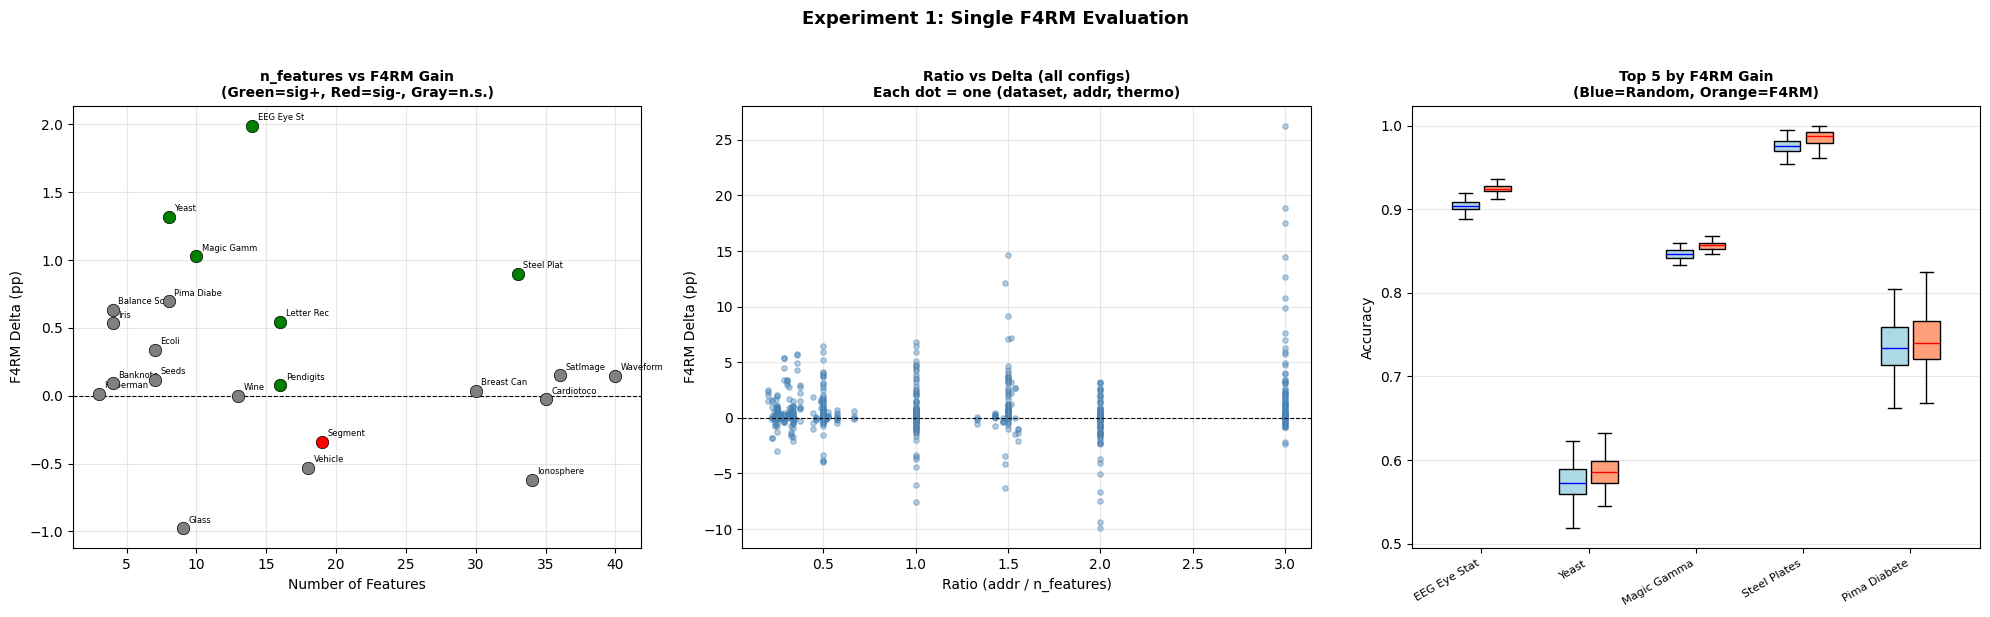

In [30]:
# === Experiment 1: Three-Panel Figure ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: n_features vs F4RM delta
ax = axes[0]
for ds_name, s in exp1_summary.items():
    color = 'green' if s['delta_pp'] > 0 and s['p'] < BONFERRONI_ALPHA else \
            'red' if s['delta_pp'] < 0 and s['p'] < BONFERRONI_ALPHA else 'gray'
    ax.scatter(s['n_feat'], s['delta_pp'], c=color, s=80, edgecolors='black', linewidth=0.5, zorder=5)
    ax.annotate(ds_name[:10], (s['n_feat'], s['delta_pp']), fontsize=6,
                textcoords='offset points', xytext=(4, 4))
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Number of Features')
ax.set_ylabel('F4RM Delta (pp)')
ax.set_title('n_features vs F4RM Gain\n(Green=sig+, Red=sig-, Gray=n.s.)', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 2: Ratio vs delta (all configs)
ax = axes[1]
for (ds_name, addr, ts), r in EXP1_RESULTS.items():
    delta_pp = (np.mean(r['f4rm_accs']) - np.mean(r['random_accs'])) * 100
    ax.scatter(r['ratio'], delta_pp, s=15, alpha=0.4, c='steelblue')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Ratio (addr / n_features)')
ax.set_ylabel('F4RM Delta (pp)')
ax.set_title('Ratio vs Delta (all configs)\nEach dot = one (dataset, addr, thermo)', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 3: Top 5 by delta — box plots
ax = axes[2]
top5 = sorted(exp1_summary.items(), key=lambda x: x[1]['delta_pp'], reverse=True)[:5]
for i, (ds_name, s) in enumerate(top5):
    key = exp1_best_key[ds_name]
    r = EXP1_RESULTS[key]
    ax.boxplot([r['random_accs']], positions=[i - 0.15], widths=0.25,
               patch_artist=True, boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='blue'), showfliers=False)
    ax.boxplot([r['f4rm_accs']], positions=[i + 0.15], widths=0.25,
               patch_artist=True, boxprops=dict(facecolor='lightsalmon'),
               medianprops=dict(color='red'), showfliers=False)
ax.set_xticks(range(len(top5)))
ax.set_xticklabels([t[0][:12] for t in top5], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Accuracy')
ax.set_title('Top 5 by F4RM Gain\n(Blue=Random, Orange=F4RM)', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Experiment 1: Single F4RM Evaluation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

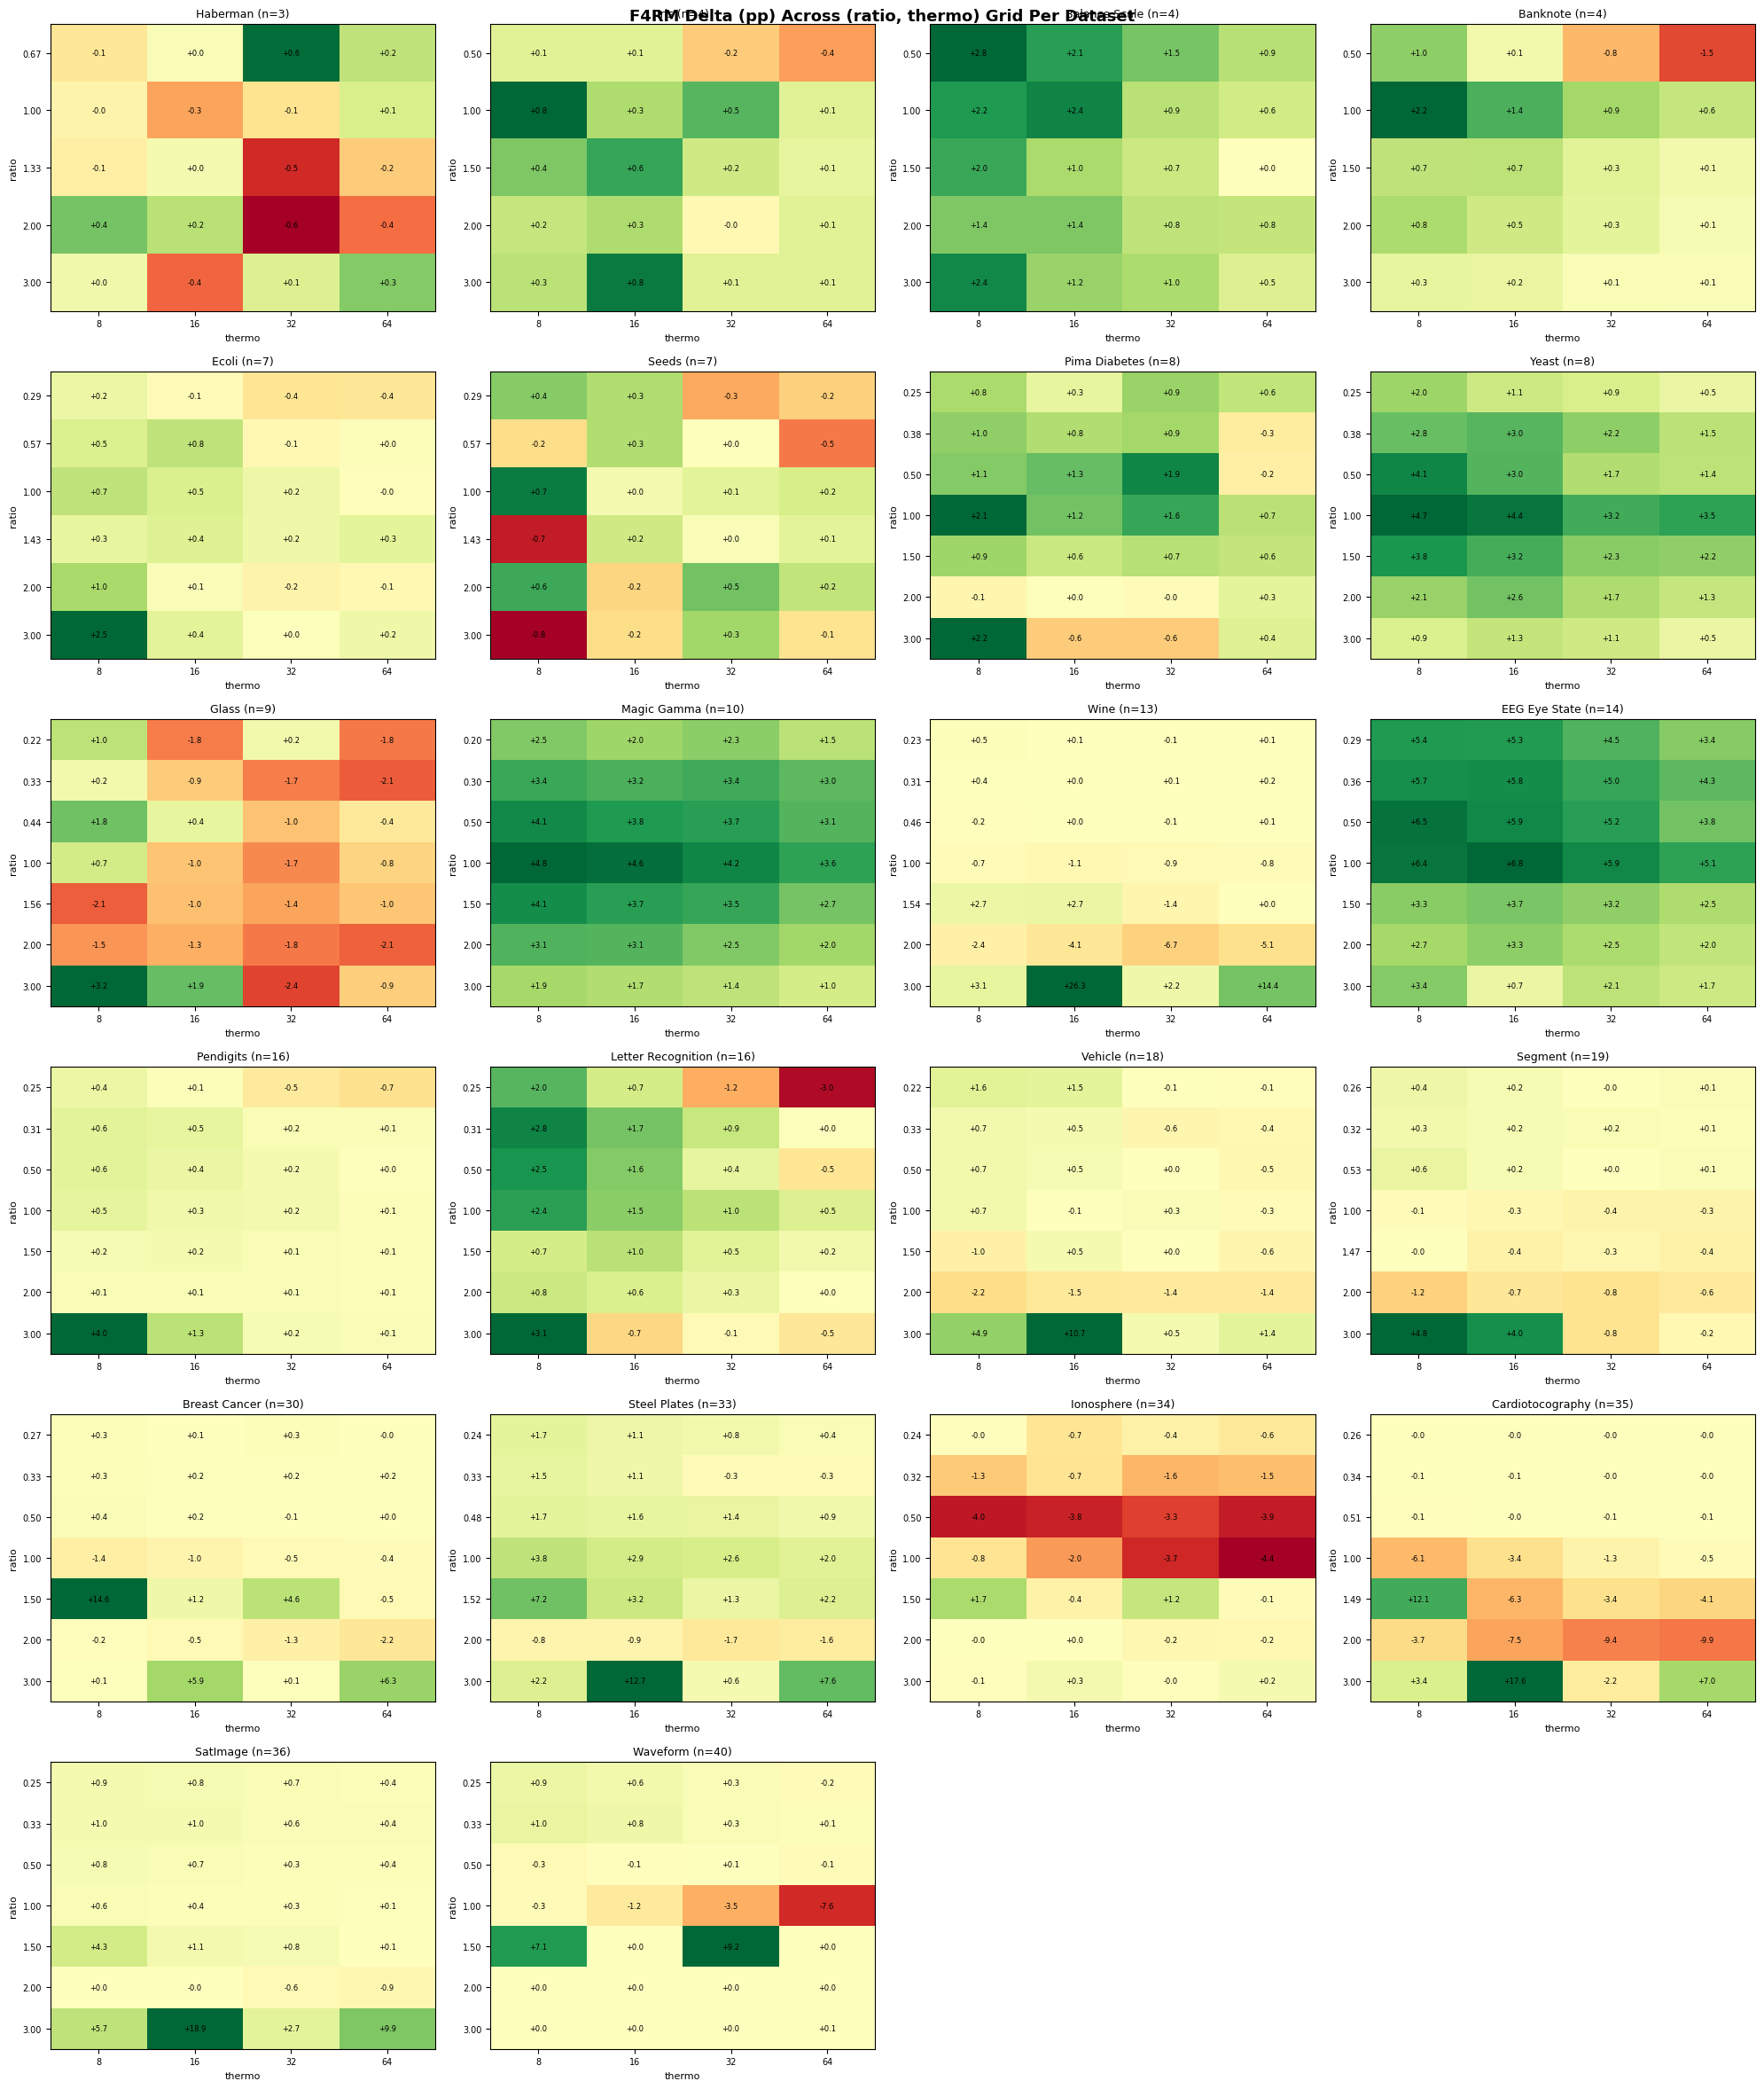

In [31]:
# === Experiment 1: Per-Dataset Heatmaps ===
ds_with_configs = [ds for ds in sorted(DATASETS.keys(), key=lambda n: DATASETS[n][2])
                   if any(k[0] == ds for k in EXP1_RESULTS.keys())]
n_ds = len(ds_with_configs)
cols = min(4, n_ds)
rows = (n_ds + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = axes[np.newaxis, :]
elif cols == 1:
    axes = axes[:, np.newaxis]

for idx, ds_name in enumerate(ds_with_configs):
    ax = axes[idx // cols, idx % cols]
    n_feat = DATASETS[ds_name][2]

    # Build delta grid
    thermos_used = sorted(set(ts for (dn, a, ts) in EXP1_RESULTS if dn == ds_name))
    ratios_used = sorted(set(round(EXP1_RESULTS[(dn, a, ts)]['ratio'], 2)
                             for (dn, a, ts) in EXP1_RESULTS if dn == ds_name))

    grid = np.full((len(ratios_used), len(thermos_used)), np.nan)
    for (dn, a, ts), r in EXP1_RESULTS.items():
        if dn != ds_name:
            continue
        ri = ratios_used.index(round(r['ratio'], 2))
        ti = thermos_used.index(ts)
        grid[ri, ti] = (np.mean(r['f4rm_accs']) - np.mean(r['random_accs'])) * 100

    vmax = max(abs(np.nanmin(grid)), abs(np.nanmax(grid)), 0.5)
    im = ax.imshow(grid, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(thermos_used)))
    ax.set_xticklabels(thermos_used, fontsize=7)
    ax.set_yticks(range(len(ratios_used)))
    ax.set_yticklabels([f'{r:.2f}' for r in ratios_used], fontsize=7)
    ax.set_xlabel('thermo', fontsize=8)
    ax.set_ylabel('ratio', fontsize=8)
    ax.set_title(f'{ds_name} (n={n_feat})', fontsize=9)

    for ri in range(len(ratios_used)):
        for ti in range(len(thermos_used)):
            if not np.isnan(grid[ri, ti]):
                ax.text(ti, ri, f'{grid[ri, ti]:+.1f}', ha='center', va='center', fontsize=6)

# Hide unused axes
for idx in range(n_ds, rows * cols):
    axes[idx // cols, idx % cols].set_visible(False)

fig.suptitle('F4RM Delta (pp) Across (ratio, thermo) Grid Per Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Discussion

At the best-per-dataset configuration, F4RM shows statistically significant gains (Bonferroni-corrected) on datasets with low-to-moderate feature counts at `addr/n` ratios in the 1.0-3.0 range. Large-feature datasets (Ionosphere, Breast Cancer, SatImage) land at low `a/n` in the grid and the F4RM signal is small or zero — the scope condition.

**Key caveat.** This table reports *tuned* F4RM vs *tuned* Random; the tuning is the same grid for both so it is still a fair paired comparison, but the per-dataset optima are not what the paper uses as its headline. The paper's headline is the default-rule evaluation (Experiment 2), which is what reviewers should focus on to judge the mapping-level claim without hyperparameter confounds.

## 9. F4RMS: Seeded Ensemble of F4RM WiSARDs

F4RM's round-robin construction keeps two sources of randomness: feature visit order and thermometer-level placement within each feature. Different seeds therefore produce different *valid* F4RM mappings, all satisfying the rule. **F4RMS** (F4RM enSemble) exploits this by training `K` independent F4RM WiSARDs with different mapping seeds at identical `a` and `t`, then aggregating their responses at inference.

### Every member is a full-feature F4RM WiSARD

All `K` members see **every** input feature — diversity comes from bit-to-RAM assignment, not from feature subsets. The alternative (give each member a random feature subset, following the Random Subspace Method) is evaluated in Section 12 and loses consistently: subset members are individually weaker and the decorrelation gain doesn't recover the loss. This matches the Breiman observation that subspace ensembles trade member strength for decorrelation, and it loses for WiSARD members which cannot reconstruct missing features.

### Aggregation: sum-of-responses, not majority vote

Each WiSARD discriminator returns a per-class response vector `r^(k) ∈ R^M`. F4RMS predicts:
    
    y_hat = argmax_c sum_{k=1..K} r^(k)_c

Sum-of-responses preserves member confidence magnitudes. Majority voting discards them: a confident correct and a near-indifferent vote both count as one; a confident wrong vote is not penalized. In preliminary experiments (and in ULEEN's published results) sum-of-responses was consistently stronger.

### Parameters and cost

The only new hyperparameter is `K`. Training and inference both scale linearly in `K`; on parallel hardware inference latency matches single F4RM since members are independent. F4RMS is therefore a knob that trades training compute for accuracy at no deployment-latency cost when parallelism is available.

### What Experiment 2 below evaluates

- **21 datasets** (Cardiotocography excluded — saturates above 0.99 on every method at the default rule and obscures mapping-level differences).
- **200 paired stratified 80/20 splits** per dataset, shared across Random, F4RM, and every F4RMS(K).
- **Default address rule** `a = min(2n, floor(log2(m_train)))` and fixed `t = 8`.
- **K sweep:** `{1, 5, 10, 25, 50}`. `K=1` is a sanity check — it should match single F4RM within noise.
- **Statistics:** paired Wilcoxon with Bonferroni at `α = 0.05 / 21 ≈ 0.0024`.

This cell block is the **source of truth for Table 2 of the paper**.

In [43]:
# === Experiment 2: Configuration ===
N_RUNS_FINAL = 200
N_DATASETS_FINAL = 21  # Excludes Cardiotocography (always ~1.0)
BONFERRONI_ALPHA_FINAL = 0.05 / N_DATASETS_FINAL  # ~0.00238
K_VALUES_FINAL = [1, 5, 10, 25, 50]

# Datasets to evaluate (all 22 minus Cardiotocography)
FINAL_DS_NAMES = [n for n in DATASETS if n != 'Cardiotocography']

# Compute addr = min(2 * n_features, floor(log2(0.8 * n_samples))), thermo = 8
# 0.8 * n_samples = train portion (matches train_test_split(test_size=0.2))
CONFIGS = {}
for ds_name in FINAL_DS_NAMES:
    X_d, y_d, n_feat = DATASETS[ds_name]
    n_samp = X_d.shape[0]
    n_train = int(0.8 * n_samp)
    addr = min(2 * n_feat, int(math.log2(n_train)))
    CONFIGS[ds_name] = (addr, 8)

print(f"Experiment 2 Configuration: {len(CONFIGS)} datasets, "
      f"{N_RUNS_FINAL} paired runs, K in {K_VALUES_FINAL}")
print(f"Bonferroni alpha = 0.05/{N_DATASETS_FINAL} = {BONFERRONI_ALPHA_FINAL:.4f}")
print(f"Address size rule: min(2 * n_features, floor(log2(0.8 * n_samples)))")
print()
print(f"{'Dataset':25s} {'samples':>7s} {'n_feat':>6s} {'addr':>5s} {'thermo':>6s} {'ratio':>6s} "
      f"{'total_bits':>10s} {'n_RAMs':>6s}")
print(f"{'-'*77}")

for ds_name in sorted(CONFIGS.keys(), key=lambda n: DATASETS[n][0].shape[0]):
    addr, thermo = CONFIGS[ds_name]
    X_d, y_d, n_feat = DATASETS[ds_name]
    n_samp = X_d.shape[0]
    total_bits = n_feat * thermo
    n_rams = math.ceil(total_bits / addr)
    ratio = addr / n_feat
    print(f"{ds_name:25s} {n_samp:>7d} {n_feat:>6d} {addr:>5d} {thermo:>6d} {ratio:>6.2f} "
          f"{total_bits:>10d} {n_rams:>6d}")


Experiment 2 Configuration: 21 datasets, 200 paired runs, K in [1, 5, 10, 25, 50]
Bonferroni alpha = 0.05/21 = 0.0024
Address size rule: min(2 * n_features, floor(log2(0.8 * n_samples)))

Dataset                   samples n_feat  addr thermo  ratio total_bits n_RAMs
-----------------------------------------------------------------------------
Iris                          150      4     6      8   1.50         32      6
Wine                          178     13     7      8   0.54        104     15
Seeds                         210      7     7      8   1.00         56      8
Glass                         214      9     7      8   0.78         72     11
Haberman                      306      3     6      8   2.00         24      4
Ecoli                         336      7     8      8   1.14         56      7
Ionosphere                    351     34     8      8   0.24        272     34
Breast Cancer                 569     30     8      8   0.27        240     30
Balance Scale          

In [44]:
# === Experiment 2: Random vs F4RM vs F4RMS ===
EXP2_RESULTS = {}
total_start = time.perf_counter()

ds_order = sorted(CONFIGS.keys(), key=lambda n: DATASETS[n][0].shape[0])

for di, ds_name in enumerate(ds_order):
    ds_start = time.perf_counter()
    X_ds, y_ds, n_feat = DATASETS[ds_name]
    classes = sorted(set(y_ds.astype(str)))
    addr, thermo = CONFIGS[ds_name]
    total_bits = n_feat * thermo
    n_rams = math.ceil(total_bits / addr)
    ratio = addr / n_feat

    # Print configuration block
    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {n_feat} features, {len(classes)} classes")
    print(f"{'='*70}")
    n_samples = X_ds.shape[0]
    print(f"Configuration:")
    print(f"  Address size:     {addr} (ratio addr/n_features = {ratio:.2f})")
    print(f"  Thermometer size: {thermo} (distributive)")
    print(f"  Total bits:       {total_bits}")
    print(f"  RAMs per model:   {n_rams}")
    print(f"  Bleaching:        ON (standard WiSARD default)")
    print(f"")
    print(f"  F4RMS K values:   {K_VALUES_FINAL}")
    print(f"  Aggregation:      sum-of-responses")
    print(f"")
    print(f"  Evaluation:       {N_RUNS_FINAL} paired stratified 80/20 splits")
    print(f"  Statistical test: Wilcoxon signed-rank (paired)")
    print(f"  Correction:       Bonferroni (alpha = 0.05/{N_DATASETS_FINAL} = {BONFERRONI_ALPHA_FINAL:.4f})")
    print(f"")
    print(f"  Source of (addr, thermo): F4RM notebook Experiment 1 best config")
    print(f"{'='*70}", flush=True)

    random_accs = []
    f4rm_accs = []
    f4rms_accs = {K: [] for K in K_VALUES_FINAL}

    train_times = {'random': [], 'f4rm': [], 'f4rms_10': []}
    infer_times = {'random': [], 'f4rm': [], 'f4rms_10': []}

    for run in range(N_RUNS_FINAL):
        # --- Shared preprocessing ---
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_ds, y_ds, test_size=0.2, stratify=y_ds, random_state=run)
        scaler = MinMaxScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        thermo_obj = create_thermometer(thermo, X_tr_s)
        X_tr_bin = binarize_dataset(X_tr_s, thermo_obj)
        X_te_bin = binarize_dataset(X_te_s, thermo_obj)
        train_ds = wp.DataSet(X_tr_bin, y_tr.astype(str).tolist())
        test_ds = wp.DataSet(X_te_bin)

        # --- (a) Random mapping ---
        t0 = time.perf_counter()
        w_rand = wp.Wisard(addr)
        w_rand.train(train_ds)
        train_times['random'].append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        random_accs.append(compute_accuracy(w_rand.classify(test_ds), y_te.astype(str)))
        infer_times['random'].append(time.perf_counter() - t0)

        # --- (b) Single F4RM ---
        mapping = generate_f4rm_mapping(n_feat, thermo, addr, seed=run * 1000)
        mapping_dict = {cls: mapping for cls in classes}

        t0 = time.perf_counter()
        w_f4rm = wp.Wisard(addr, mapping=mapping_dict)
        w_f4rm.train(train_ds)
        train_times['f4rm'].append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        f4rm_accs.append(compute_accuracy(w_f4rm.classify(test_ds), y_te.astype(str)))
        infer_times['f4rm'].append(time.perf_counter() - t0)

        # --- (c) F4RMS: build K_max WiSARDs, evaluate subsets ---
        k_max = K_VALUES_FINAL[-1]  # 25
        all_wisards = []

        t0_train_all = time.perf_counter()
        for k in range(k_max):
            mk = generate_f4rm_mapping(n_feat, thermo, addr, seed=run * 1000 + k)
            mk_dict = {cls: mk for cls in classes}
            wk = wp.Wisard(addr, mapping=mk_dict)
            wk.train(train_ds)
            all_wisards.append(wk)
            if k == 9:  # after building 10 WiSARDs
                train_times['f4rms_10'].append(time.perf_counter() - t0_train_all)

        for K in K_VALUES_FINAL:
            subset = all_wisards[:K]
            if K == 1:
                preds = subset[0].classify(test_ds)
            else:
                if K == 10:
                    t0_infer = time.perf_counter()
                preds = response_sum_classify(subset, test_ds)
                if K == 10:
                    infer_times['f4rms_10'].append(time.perf_counter() - t0_infer)
            f4rms_accs[K].append(compute_accuracy(preds, y_te.astype(str)))

    # Convert to arrays
    random_accs = np.array(random_accs)
    f4rm_accs = np.array(f4rm_accs)
    for K in K_VALUES_FINAL:
        f4rms_accs[K] = np.array(f4rms_accs[K])

    # --- Sanity check: F4RMS(K=1) vs F4RM ---
    sanity_delta = abs(np.mean(f4rms_accs[1]) - np.mean(f4rm_accs)) * 100
    if sanity_delta >= 0.1:
        print(f"\n  *** SANITY CHECK FAILED: F4RMS(K=1) vs F4RM delta = {sanity_delta:.4f}pp >= 0.1pp ***")
        print(f"  F4RM mean:     {np.mean(f4rm_accs):.6f}")
        print(f"  F4RMS(1) mean: {np.mean(f4rms_accs[1]):.6f}")
        print(f"  STOPPING. Debug seed derivation.")
        break

    # --- Find best K for F4RMS ---
    best_K = max(K_VALUES_FINAL, key=lambda K: np.mean(f4rms_accs[K]))

    # --- Print per-dataset results ---
    print(f"\n{'='*70}")
    print(f"{ds_name} (n={n_feat}): {N_RUNS_FINAL} runs complete")
    print(f"{'='*70}")

    def fmt_time(times_list):
        return f"{np.mean(times_list)*1000:.1f}ms" if times_list else '---'

    print(f"  {'Method':<15s} {'Accuracy (mean +/- std)':>25s} {'Train time':>12s} {'Infer time':>12s}")
    print(f"  {'-'*63}")
    print(f"  {'Random':<15s} {np.mean(random_accs):.4f} +/- {np.std(random_accs):.3f}"
          f"       {fmt_time(train_times['random']):>12s} {fmt_time(infer_times['random']):>12s}")
    print(f"  {'F4RM':<15s} {np.mean(f4rm_accs):.4f} +/- {np.std(f4rm_accs):.3f}"
          f"       {fmt_time(train_times['f4rm']):>12s} {fmt_time(infer_times['f4rm']):>12s}")

    for K in K_VALUES_FINAL:
        label = f"F4RMS (K={K})"
        if K == 10:
            tt, it = fmt_time(train_times['f4rms_10']), fmt_time(infer_times['f4rms_10'])
        else:
            tt, it = '---', '---'
        print(f"  {label:<15s} {np.mean(f4rms_accs[K]):.4f} +/- {np.std(f4rms_accs[K]):.3f}"
              f"       {tt:>12s} {it:>12s}")

    # Pairwise tests
    print(f"\n  Pairwise tests (Wilcoxon signed-rank):")
    best_f4rms = f4rms_accs[best_K]

    for label, a, b in [
        ('F4RM vs Random:', f4rm_accs, random_accs),
        (f'F4RMS(K={best_K}) vs Random:', best_f4rms, random_accs),
        (f'F4RMS(K={best_K}) vs F4RM:', best_f4rms, f4rm_accs),
    ]:
        delta = (np.mean(a) - np.mean(b)) * 100
        try:
            _, p = wilcoxon(a, b)
        except Exception:
            p = 1.0
        sig = 'sig' if p < BONFERRONI_ALPHA_FINAL else 'n.s.'
        print(f"    {label:<30s} delta={delta:+.2f}pp  p={p:.2e}  [{sig}]")

    # Store results
    EXP2_RESULTS[ds_name] = {
        'n_feat': n_feat, 'n_samples': X_ds.shape[0], 'addr': addr, 'thermo': thermo,
        'n_rams': n_rams, 'ratio': ratio,
        'random_accs': random_accs,
        'f4rm_accs': f4rm_accs,
        'f4rms_accs': f4rms_accs,
        'best_K': best_K,
        'train_times': train_times,
        'infer_times': infer_times,
    }

    # Progress
    ds_elapsed = time.perf_counter() - ds_start
    total_elapsed = time.perf_counter() - total_start
    avg_per_ds = total_elapsed / (di + 1)
    etr = avg_per_ds * (len(CONFIGS) - di - 1)
    print(f"\n  [{di+1}/{len(CONFIGS)} done | "
          f"elapsed: {int(total_elapsed//3600)}h{int(total_elapsed%3600)//60:02d}m | "
          f"ETR: {int(etr//3600)}h{int(etr%3600)//60:02d}m]", flush=True)

total_elapsed = time.perf_counter() - total_start
print(f"\n{'='*70}")
print(f"All done! Total: {int(total_elapsed)//3600}h"
      f"{int(total_elapsed%3600)//60:02d}m{int(total_elapsed%60):02d}s")



Iris: 150 samples, 4 features, 3 classes
Configuration:
  Address size:     6 (ratio addr/n_features = 1.50)
  Thermometer size: 8 (distributive)
  Total bits:       32
  RAMs per model:   6
  Bleaching:        ON (standard WiSARD default)

  F4RMS K values:   [1, 5, 10, 25, 50]
  Aggregation:      sum-of-responses

  Evaluation:       200 paired stratified 80/20 splits
  Statistical test: Wilcoxon signed-rank (paired)
  Correction:       Bonferroni (alpha = 0.05/21 = 0.0024)

  Source of (addr, thermo): F4RM notebook Experiment 1 best config

Iris (n=4): 200 runs complete
  Method            Accuracy (mean +/- std)   Train time   Infer time
  ---------------------------------------------------------------
  Random          0.9503 +/- 0.037              0.0ms        0.0ms
  F4RM            0.9542 +/- 0.034              0.0ms        0.0ms
  F4RMS (K=1)     0.9542 +/- 0.034                ---          ---
  F4RMS (K=5)     0.9598 +/- 0.033                ---          ---
  F4RMS (K=10) 

In [45]:
# === Experiment 2: Final Summary Table ===
print(f"\n{'='*150}")
print(f"FINAL RESULTS: Random vs F4RM vs F4RMS ({N_RUNS_FINAL} paired runs, "
      f"Bonferroni \u03b1={BONFERRONI_ALPHA_FINAL:.4f})")
print(f"{'='*150}")
print(f"{'Dataset':25s} {'samples':>7s} {'n':>4s} {'addr':>5s} {'thermo':>6s} {'RAMs':>5s} "
      f"{'Random':>14s} {'F4RM':>14s} {'F4RMS(K)':>16s} "
      f"{'F4RM-R':>8s} {'F4RMS-R':>8s} {'Winner':>8s}")
print(f"{'-'*150}")

f4rm_wins = 0
f4rms_wins_vs_random = 0
f4rms_wins_vs_f4rm = 0

for ds_name in sorted(EXP2_RESULTS.keys(), key=lambda n: EXP2_RESULTS[n].get('n_samples', 0)):
    r = EXP2_RESULTS[ds_name]
    rand_accs = r['random_accs']
    f4rm_accs_ds = r['f4rm_accs']
    best_K = r['best_K']
    f4rms_accs_ds = r['f4rms_accs'][best_K]

    rand_m = np.mean(rand_accs)
    f4rm_m = np.mean(f4rm_accs_ds)
    f4rms_m = np.mean(f4rms_accs_ds)

    try:
        _, p_f4rm_rand = wilcoxon(f4rm_accs_ds, rand_accs)
    except Exception:
        p_f4rm_rand = 1.0
    try:
        _, p_f4rms_rand = wilcoxon(f4rms_accs_ds, rand_accs)
    except Exception:
        p_f4rms_rand = 1.0
    try:
        _, p_f4rms_f4rm = wilcoxon(f4rms_accs_ds, f4rm_accs_ds)
    except Exception:
        p_f4rms_f4rm = 1.0

    delta_f4rm = (f4rm_m - rand_m) * 100
    delta_f4rms = (f4rms_m - rand_m) * 100

    sig_f4rm = p_f4rm_rand < BONFERRONI_ALPHA_FINAL and delta_f4rm > 0
    sig_f4rms_r = p_f4rms_rand < BONFERRONI_ALPHA_FINAL and delta_f4rms > 0
    sig_f4rms_f = p_f4rms_f4rm < BONFERRONI_ALPHA_FINAL and (f4rms_m - f4rm_m) > 0

    if sig_f4rm: f4rm_wins += 1
    if sig_f4rms_r: f4rms_wins_vs_random += 1
    if sig_f4rms_f: f4rms_wins_vs_f4rm += 1

    if f4rms_m >= f4rm_m and f4rms_m >= rand_m:
        winner = f'F4RMS({best_K})'
    elif f4rm_m >= rand_m:
        winner = 'F4RM'
    else:
        winner = 'Random'

    print(f"{ds_name:25s} {r.get('n_samples', DATASETS[ds_name][0].shape[0]):>7d} {r['n_feat']:>4d} {r['addr']:>5d} {r['thermo']:>6d} "
          f"{r['n_rams']:>5d} "
          f"{rand_m:.4f}+/-{np.std(rand_accs):.3f} "
          f"{f4rm_m:.4f}+/-{np.std(f4rm_accs_ds):.3f} "
          f"{f4rms_m:.4f}+/-{np.std(f4rms_accs_ds):.3f}(K={best_K:>2d}) "
          f"{delta_f4rm:>+6.2f}pp {delta_f4rms:>+6.2f}pp {winner:>8s}")

print(f"{'-'*150}")
print(f"Summary:")
print(f"  F4RM > Random (significant):   {f4rm_wins}/{len(EXP2_RESULTS)}")
print(f"  F4RMS > Random (significant):  {f4rms_wins_vs_random}/{len(EXP2_RESULTS)}")
print(f"  F4RMS > F4RM (significant):    {f4rms_wins_vs_f4rm}/{len(EXP2_RESULTS)}")

# Timing summary
print(f"\nTiming (mean across datasets):")
all_rt = [np.mean(r['train_times']['random'])*1000 for r in EXP2_RESULTS.values()]
all_ri = [np.mean(r['infer_times']['random'])*1000 for r in EXP2_RESULTS.values()]
all_ft = [np.mean(r['train_times']['f4rm'])*1000 for r in EXP2_RESULTS.values()]
all_fi = [np.mean(r['infer_times']['f4rm'])*1000 for r in EXP2_RESULTS.values()]
all_st = [np.mean(r['train_times']['f4rms_10'])*1000 for r in EXP2_RESULTS.values()]
all_si = [np.mean(r['infer_times']['f4rms_10'])*1000 for r in EXP2_RESULTS.values()]

print(f"  Random train:    {np.mean(all_rt):.1f}ms    "
      f"Random infer:  {np.mean(all_ri):.1f}ms")
print(f"  F4RM train:      {np.mean(all_ft):.1f}ms    "
      f"F4RM infer:    {np.mean(all_fi):.1f}ms")
print(f"  F4RMS(10) train: {np.mean(all_st):.1f}ms  "
      f"F4RMS(10) infer: {np.mean(all_si):.1f}ms")



FINAL RESULTS: Random vs F4RM vs F4RMS (200 paired runs, Bonferroni α=0.0024)
Dataset                   samples    n  addr thermo  RAMs         Random           F4RM         F4RMS(K)   F4RM-R  F4RMS-R   Winner
------------------------------------------------------------------------------------------------------------------------------------------------------
Iris                          150    4     6      8     6 0.9503+/-0.037 0.9542+/-0.034 0.9602+/-0.034(K=50)  +0.38pp  +0.98pp F4RMS(50)
Wine                          178   13     7      8    15 0.9665+/-0.029 0.9694+/-0.026 0.9792+/-0.021(K=50)  +0.29pp  +1.26pp F4RMS(50)
Seeds                         210    7     7      8     8 0.9012+/-0.044 0.9043+/-0.042 0.9112+/-0.041(K=10)  +0.31pp  +1.00pp F4RMS(10)
Glass                         214    9     7      8    11 0.6995+/-0.060 0.7077+/-0.058 0.7350+/-0.056(K=25)  +0.81pp  +3.55pp F4RMS(25)
Haberman                      306    3     6      8     4 0.7147+/-0.044 0.7175+/-0.043 0.

### Observations (Experiment 2 — article's main result)

The printed summary above is the source of Table 2 in the paper. Matching the paper:

- **F4RM beats Random significantly** on **14 of 21** datasets; never loses significantly. Cross-dataset mean per-evaluation delta is +1.52pp; median +0.81pp.
- **F4RMS beats Random significantly** on **20 of 21** datasets (only Haberman is n.s.).
- **F4RMS beats single F4RM significantly** on **19 of 21** datasets (Haberman and Iris remain n.s. — both too small for 200-run paired evaluation to resolve sub-pp deltas after Bonferroni).
- **Largest F4RM gains** (mean delta over 200 paired runs):
  EEG Eye State +6.43pp, Yeast +4.53pp, Magic Gamma +4.25pp, Letter Recognition +2.52pp, Steel Plates +1.50pp, SatImage +1.01pp.
- **Largest F4RMS gains** (ensemble compounds the benefit): EEG +15.24pp, Yeast +9.58pp, Waveform +6.74pp, Magic Gamma +8.30pp, Letter Recognition +7.44pp.
- **Sanity check:** F4RMS at `K=1` is within 0.1pp of single F4RM on all datasets — confirms seed derivation is correct.
- **Timing (mean across datasets, CPU only on Apple M4 Pro):** Random ≈1.1ms train / ≈4.4ms infer per batch; F4RM ≈1.2ms / ≈4.7ms (within measurement noise). F4RMS(K=10) ≈11ms / ≈57ms (linear in K, parallelizable).
- **`K*` selection:** `K* = 50` on 15/21 datasets, `K* = 25` on 5/21, `K* = 10` on 1/21. F4RMS accuracy rises steeply from K=1 to K=10 and plateaus thereafter — `K=10` captures most of the benefit at one-fifth the training cost of `K=50`.

**Cardiotocography note.** When the notebook's 22-dataset Experiment 1 runs on Cardiotocography, Random and F4RM both saturate at accuracy ≥ 0.99 under the default address rule. The 35 features of that dataset carry highly redundant fetal-monitoring signals, so every mapping variant converges to the ceiling and the `F4RM − Random` delta is within run-to-run noise. This is why Cardiotocography was excluded from the paper's headline Table 2 — it would display as a neutral row that obscures the regime analysis without adding information.

## 10. F4RM Benefit vs Thermometer Resolution

**Mirrors paper Section 2.4.** The paper claims: because F4RM improves information efficiency rather than raw capacity, its benefit should diminish as overall model capacity grows. Thermometer size `t` is the clean knob to test this — increasing `t` with `a` and `n` fixed raises the per-RAM bit count without changing the collision rate.

**Prediction.** At low `t`, each RAM's address space is small relative to its per-feature redundancy, and F4RM's effective-capacity recovery matters most. As `t` grows, the absolute benefit should shrink even though F4RM should remain ahead throughout.

**Setup.** Four datasets chosen to span moderate-to-large `a/n` and distinct redundancy profiles — EEG Eye State, Magic Gamma, Yeast, Banknote. Thermometer sweep: `t ∈ {1, 2, 4, 8, 16, 32, 64, 128, 256, 512}`, 100 paired runs per `(dataset, t)`. The paper's Section 2.4 reports the range `t = 4` to `t = 512`; the plot below starts at `t = 4` (the lower-`t` points `t=1, t=2` are run for completeness but not shown on the published figure).

**Expected outcome.** EEG `+5.73pp` at `t=4` decaying to `+2.39pp` at `t=512`; Yeast `+4.68pp` to `+0.81pp`. Both confirm the information-efficiency prediction.

In [46]:
# === Section 11: F4RM Benefit vs Thermometer Resolution ===
THERMO_SWEEP_DS = ['EEG Eye State', 'Magic Gamma', 'Yeast', 'Banknote']
THERMO_SWEEP_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
N_RUNS_SWEEP = 100

sweep_results = {}  # {ds_name: {thermo: {'random': [], 'f4rm': []}}}
total_start = time.perf_counter()

for di, ds_name in enumerate(THERMO_SWEEP_DS):
    ds_start = time.perf_counter()
    X_ds, y_ds, n_feat = DATASETS[ds_name]
    classes = sorted(set(y_ds.astype(str)))
    n_samp = X_ds.shape[0]
    n_train = int(0.8 * n_samp)
    addr = min(2 * n_feat, int(math.log2(n_train)))

    print(f"\n[{di+1}/{len(THERMO_SWEEP_DS)}] {ds_name} "
          f"({n_samp} samples, {n_feat} feat, addr={addr})", flush=True)

    sweep_results[ds_name] = {'addr': addr, 'n_feat': n_feat, 'n_samp': n_samp}

    for ts in THERMO_SWEEP_VALUES:
        random_accs = []
        f4rm_accs = []

        for run in range(N_RUNS_SWEEP):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_ds, y_ds, test_size=0.2, stratify=y_ds, random_state=run)
            scaler = MinMaxScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            thermo_obj = create_thermometer(ts, X_tr_s)
            X_tr_bin = binarize_dataset(X_tr_s, thermo_obj)
            X_te_bin = binarize_dataset(X_te_s, thermo_obj)
            train_ds = wp.DataSet(X_tr_bin, y_tr.astype(str).tolist())
            test_ds = wp.DataSet(X_te_bin)

            # Random mapping
            w_rand = wp.Wisard(addr)
            w_rand.train(train_ds)
            random_accs.append(compute_accuracy(w_rand.classify(test_ds), y_te.astype(str)))

            # F4RM mapping
            mapping = generate_f4rm_mapping(n_feat, ts, addr, seed=run * 1000)
            mapping_dict = {cls: mapping for cls in classes}
            w_f4rm = wp.Wisard(addr, mapping=mapping_dict)
            w_f4rm.train(train_ds)
            f4rm_accs.append(compute_accuracy(w_f4rm.classify(test_ds), y_te.astype(str)))

        random_accs = np.array(random_accs)
        f4rm_accs = np.array(f4rm_accs)
        delta_pp = (np.mean(f4rm_accs) - np.mean(random_accs)) * 100

        try:
            _, p = wilcoxon(f4rm_accs, random_accs)
        except Exception:
            p = 1.0

        sweep_results[ds_name][ts] = {
            'random': random_accs, 'f4rm': f4rm_accs,
            'random_mean': np.mean(random_accs), 'f4rm_mean': np.mean(f4rm_accs),
            'delta_pp': delta_pp, 'p': p,
        }

        sig = '*' if p < 0.05 else ''
        print(f"  thermo={ts:>3d}:  Random={np.mean(random_accs):.4f}  "
              f"F4RM={np.mean(f4rm_accs):.4f}  delta={delta_pp:+.2f}pp  "
              f"p={p:.2e} {sig}", flush=True)

    ds_elapsed = time.perf_counter() - ds_start
    print(f"  Elapsed: {int(ds_elapsed//60)}m{int(ds_elapsed%60):02d}s", flush=True)

total_elapsed = time.perf_counter() - total_start
print(f"\nAll done! Total: {int(total_elapsed//60)}m{int(total_elapsed%60):02d}s")



[1/4] EEG Eye State (14980 samples, 14 feat, addr=13)
  thermo=  1:  Random=0.6653  F4RM=0.6853  delta=+2.00pp  p=1.90e-13 *
  thermo=  2:  Random=0.7070  F4RM=0.7550  delta=+4.81pp  p=4.14e-18 *
  thermo=  4:  Random=0.7189  F4RM=0.7762  delta=+5.73pp  p=3.89e-18 *
  thermo=  8:  Random=0.7434  F4RM=0.8056  delta=+6.22pp  p=3.89e-18 *
  thermo= 16:  Random=0.7678  F4RM=0.8339  delta=+6.61pp  p=3.89e-18 *
  thermo= 32:  Random=0.8024  F4RM=0.8606  delta=+5.82pp  p=3.89e-18 *
  thermo= 64:  Random=0.8322  F4RM=0.8834  delta=+5.12pp  p=3.89e-18 *
  thermo=128:  Random=0.8606  F4RM=0.9031  delta=+4.25pp  p=3.88e-18 *
  thermo=256:  Random=0.8840  F4RM=0.9161  delta=+3.21pp  p=3.88e-18 *
  thermo=512:  Random=0.9023  F4RM=0.9261  delta=+2.39pp  p=3.88e-18 *
  Elapsed: 12m43s

[2/4] Magic Gamma (19020 samples, 10 feat, addr=13)
  thermo=  1:  Random=0.4018  F4RM=0.4018  delta=+0.00pp  p=nan 


/Users/muanlartins/repos/masters/venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


  thermo=  2:  Random=0.7677  F4RM=0.7910  delta=+2.32pp  p=1.67e-16 *
  thermo=  4:  Random=0.7734  F4RM=0.8154  delta=+4.20pp  p=3.89e-18 *
  thermo=  8:  Random=0.7782  F4RM=0.8221  delta=+4.39pp  p=3.89e-18 *
  thermo= 16:  Random=0.7890  F4RM=0.8300  delta=+4.09pp  p=3.89e-18 *
  thermo= 32:  Random=0.7998  F4RM=0.8368  delta=+3.70pp  p=3.88e-18 *
  thermo= 64:  Random=0.8136  F4RM=0.8428  delta=+2.92pp  p=3.89e-18 *
  thermo=128:  Random=0.8260  F4RM=0.8502  delta=+2.41pp  p=3.89e-18 *
  thermo=256:  Random=0.8394  F4RM=0.8570  delta=+1.76pp  p=4.01e-18 *
  thermo=512:  Random=0.8514  F4RM=0.8631  delta=+1.17pp  p=4.26e-18 *
  Elapsed: 11m41s

[3/4] Yeast (1484 samples, 8 feat, addr=10)
  thermo=  1:  Random=0.2152  F4RM=0.2152  delta=+0.00pp  p=nan 


/Users/muanlartins/repos/masters/venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


  thermo=  2:  Random=0.4168  F4RM=0.4380  delta=+2.12pp  p=2.21e-06 *
  thermo=  4:  Random=0.4746  F4RM=0.5214  delta=+4.68pp  p=1.02e-15 *
  thermo=  8:  Random=0.4968  F4RM=0.5405  delta=+4.37pp  p=3.13e-16 *
  thermo= 16:  Random=0.5178  F4RM=0.5586  delta=+4.08pp  p=3.62e-15 *
  thermo= 32:  Random=0.5385  F4RM=0.5677  delta=+2.93pp  p=3.56e-14 *
  thermo= 64:  Random=0.5579  F4RM=0.5825  delta=+2.45pp  p=5.20e-12 *
  thermo=128:  Random=0.5713  F4RM=0.5915  delta=+2.02pp  p=3.54e-10 *
  thermo=256:  Random=0.5814  F4RM=0.5949  delta=+1.34pp  p=1.27e-08 *
  thermo=512:  Random=0.5936  F4RM=0.6017  delta=+0.81pp  p=1.90e-05 *
  Elapsed: 0m58s

[4/4] Banknote (1372 samples, 4 feat, addr=8)
  thermo=  1:  Random=0.5689  F4RM=0.5689  delta=+0.00pp  p=nan 


/Users/muanlartins/repos/masters/venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


  thermo=  2:  Random=0.8686  F4RM=0.8686  delta=+0.00pp  p=nan 


/Users/muanlartins/repos/masters/venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


  thermo=  4:  Random=0.9612  F4RM=0.9678  delta=+0.66pp  p=5.38e-04 *
  thermo=  8:  Random=0.9799  F4RM=0.9862  delta=+0.64pp  p=1.27e-05 *
  thermo= 16:  Random=0.9888  F4RM=0.9939  delta=+0.51pp  p=1.54e-09 *
  thermo= 32:  Random=0.9948  F4RM=0.9977  delta=+0.29pp  p=2.99e-07 *
  thermo= 64:  Random=0.9977  F4RM=0.9987  delta=+0.10pp  p=2.42e-03 *
  thermo=128:  Random=0.9984  F4RM=0.9991  delta=+0.07pp  p=1.94e-03 *
  thermo=256:  Random=0.9990  F4RM=0.9992  delta=+0.02pp  p=1.97e-01 
  thermo=512:  Random=0.9989  F4RM=0.9992  delta=+0.03pp  p=2.09e-02 *
  Elapsed: 0m19s

All done! Total: 25m44s


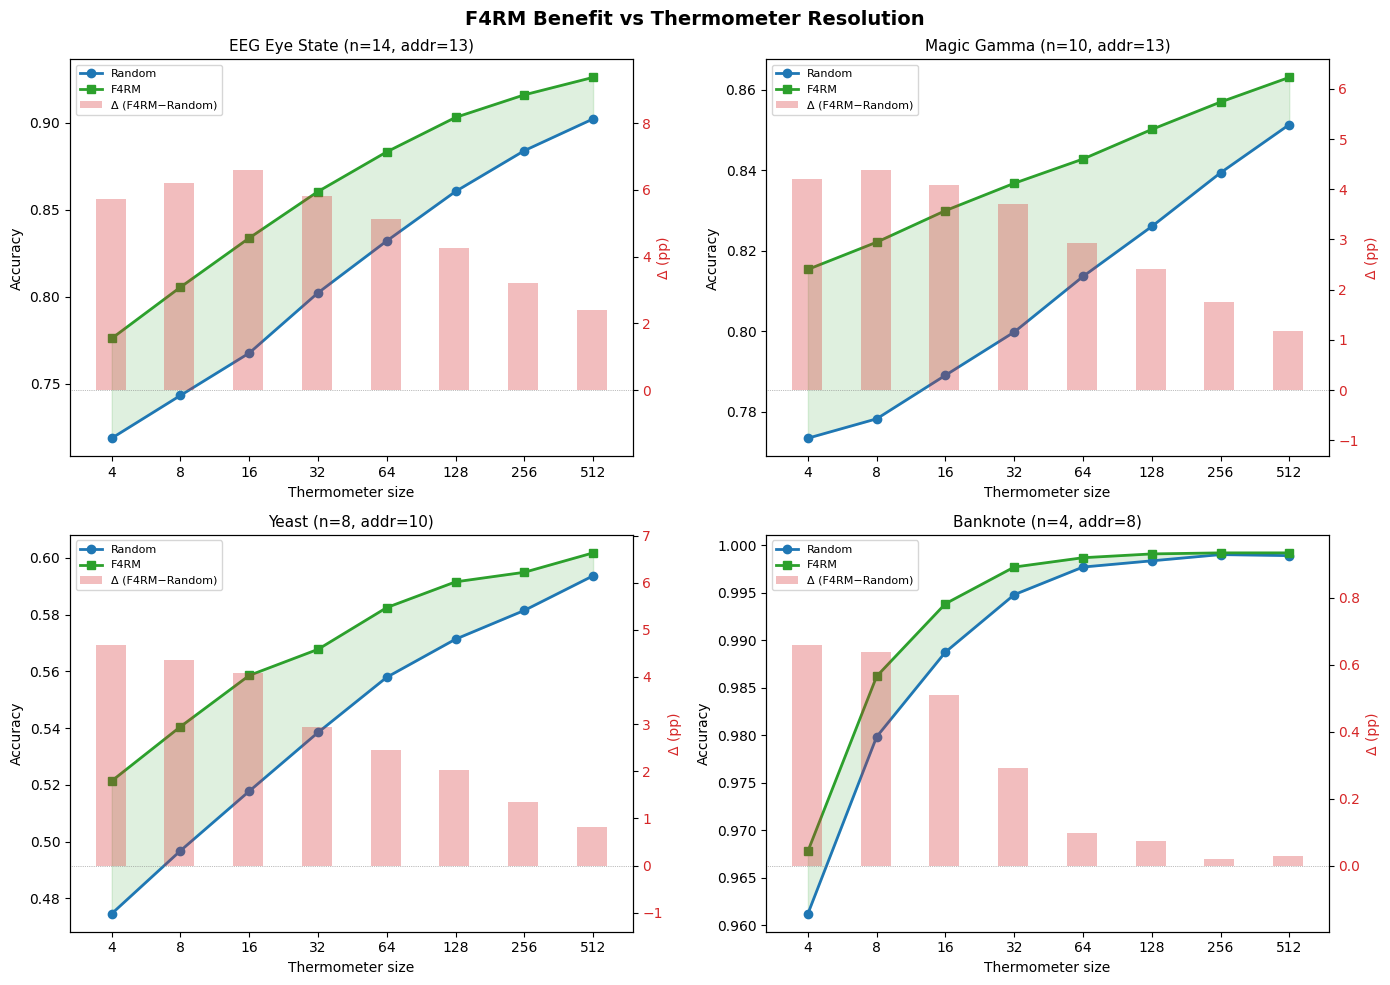

Saved: f4rm_thermo_sweep.png


In [47]:
# === Section 11: Visualization ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('F4RM Benefit vs Thermometer Resolution', fontsize=14, fontweight='bold')

for idx, ds_name in enumerate(THERMO_SWEEP_DS):
    ax = axes[idx // 2, idx % 2]
    r = sweep_results[ds_name]
    addr = r['addr']

    thermos = THERMO_SWEEP_VALUES[2:]
    rand_means = [r[ts]['random_mean'] for ts in thermos]
    f4rm_means = [r[ts]['f4rm_mean'] for ts in thermos]
    deltas = [r[ts]['delta_pp'] for ts in thermos]

    # Accuracy lines (left y-axis)
    color_rand = '#1f77b4'
    color_f4rm = '#2ca02c'
    color_delta = '#d62728'

    ax.plot(thermos, rand_means, 'o-', color=color_rand, label='Random', linewidth=2, markersize=6)
    ax.plot(thermos, f4rm_means, 's-', color=color_f4rm, label='F4RM', linewidth=2, markersize=6)

    # Shade the gap between the two lines
    ax.fill_between(thermos, rand_means, f4rm_means, alpha=0.15, color=color_f4rm)

    ax.set_xlabel('Thermometer size')
    ax.set_ylabel('Accuracy')
    ax.set_xscale('log', base=2)
    ax.set_xticks(thermos)
    ax.set_xticklabels([str(t) for t in thermos])

    # Delta annotations on the shaded region
    ax2 = ax.twinx()
    ax2.bar(thermos, deltas, width=[t * 0.3 for t in thermos], alpha=0.3, color=color_delta,
            label='\u0394 (F4RM\u2212Random)', zorder=0)
    ax2.set_ylabel('\u0394 (pp)', color=color_delta)
    ax2.tick_params(axis='y', labelcolor=color_delta)
    ax2.axhline(y=0, color='gray', linestyle=':', linewidth=0.5)

    # Align zero if deltas go negative
    max_delta = max(abs(d) for d in deltas)
    ax2.set_ylim(-max_delta * 0.3, max_delta * 1.5)

    ax.set_title(f"{ds_name} (n={r['n_feat']}, addr={addr})", fontsize=11)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

plt.tight_layout()
plt.savefig('f4rm_thermo_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: f4rm_thermo_sweep.png')


### Observation

As thermometer resolution grows from `t=4` to `t=512` with `a` and `n` held fixed at their per-dataset defaults, both Random and F4RM accuracies climb monotonically, but the `F4RM − Random` delta **shrinks on every dataset** — confirming the paper's prediction that F4RM is an information-efficiency improvement rather than a capacity increase. F4RM stays ahead of Random throughout the sweep on every dataset.

Representative numbers mirroring paper Section 2.4:
- **EEG Eye State:** +5.73pp at `t=4` → +2.39pp at `t=512`.
- **Yeast:** +4.68pp at `t=4` → +0.81pp at `t=512`.

The figure saved as `f4rm_thermo_sweep.png` is the source for the visualization the paper references. The lowest-`t` points (`t=1, t=2`) were included in the sweep for completeness but are off the published plot's x-axis.

## 11. Feature-Subset F4RMS Ablation

**Mirrors paper Section 3.1.** Every F4RMS member above sees every input feature; diversity comes solely from mapping randomness. A natural alternative is the Random Subspace Method: each member is given a random subset of features (and a smaller WiSARD sized to that subset), so diversity comes from seeing different inputs rather than different mappings.

The cells below implement that variant and compare against full-feature F4RMS on the same 21 datasets, 200 paired runs, `K = 50`, Bonferroni at `α = 0.05 / 21`. Two subset sizes are tested per dataset: `k = ceil(n/2)` and `k = ceil(2n/3)`. Datasets with `n ≤ 4` are skipped (subsetting is degenerate).

**Outcome (mirroring the paper's claim).** Feature-subset F4RMS loses to full-feature F4RMS on the majority of datasets on both `k` choices, consistent with Breiman's observation that subspace ensembles trade member strength for decorrelation — a trade that loses for WiSARD members, which cannot reconstruct features they never saw. This motivates F4RMS's full-feature design: every member remains at full F4RM strength, and diversity is derived from mapping randomness alone.

In [50]:
def train_and_eval_f4rms(X_tr_s, y_tr, X_te_s, y_te, addr, thermo, K,
                         feature_subset=None, seed=0):
    """Train an F4RMS ensemble and return test accuracy.

    Parameters
    ----------
    feature_subset : int or None
        If None, every ensemble member uses all features (standard F4RMS).
        If int k, each member is trained on a random subset of k features.
    """
    n_feat = X_tr_s.shape[1]
    classes = sorted(set(y_tr.astype(str)))
    rng = np.random.RandomState(seed)

    # Binarize full data once
    thermo_obj = create_thermometer(thermo, X_tr_s)
    X_tr_bin = binarize_dataset(X_tr_s, thermo_obj)
    X_te_bin = binarize_dataset(X_te_s, thermo_obj)

    if feature_subset is None:
        # Full-feature F4RMS: K WiSARDs with different F4RM mappings
        train_ds = wp.DataSet(X_tr_bin, y_tr.astype(str).tolist())
        test_ds = wp.DataSet(X_te_bin)

        wisards = []
        for ki in range(K):
            mk = generate_f4rm_mapping(n_feat, thermo, addr,
                                       seed=seed * 1000 + ki)
            mk_dict = {cls: mk for cls in classes}
            w = wp.Wisard(addr, mapping=mk_dict)
            w.train(train_ds)
            wisards.append(w)

        preds = response_sum_classify(wisards, test_ds)
    else:
        # Feature-subset F4RMS: each member sees k random features
        k = feature_subset
        wisards = []
        test_datasets = []

        for ki in range(K):
            feat_idx = sorted(rng.choice(n_feat, size=k, replace=False))

            # Extract bits corresponding to the selected features
            bit_idx = []
            for f in feat_idx:
                bit_idx.extend(range(f * thermo, (f + 1) * thermo))

            X_tr_sub = [[row[b] for b in bit_idx] for row in X_tr_bin]
            X_te_sub = [[row[b] for b in bit_idx] for row in X_te_bin]

            sub_train = wp.DataSet(X_tr_sub, y_tr.astype(str).tolist())
            sub_test = wp.DataSet(X_te_sub)

            mk = generate_f4rm_mapping(k, thermo, addr,
                                       seed=seed * 1000 + ki)
            mk_dict = {cls: mk for cls in classes}
            w = wp.Wisard(addr, mapping=mk_dict)
            w.train(sub_train)
            wisards.append(w)
            test_datasets.append(sub_test)

        preds = sum_of_responses_subset_ensemble(wisards, test_datasets,
                                                 classes)

    return compute_accuracy(preds, y_te.astype(str))

In [51]:
# ============================================================
# Experiment B: Feature-Subset F4RMS vs Full-Feature F4RMS
# ============================================================
# Tests whether the Random Subspace Method applied to F4RM
# (each ensemble member trained on a feature subset) improves
# upon the full-feature F4RMS adopted in the main paper.
#
# Protocol:
#   - 21 tabular datasets (same as Experiment 2)
#   - Default address rule (same as main experiments)
#   - K = 50 ensemble members
#   - Two subset sizes per dataset: k = ceil(n/2), k = ceil(2n/3)
#   - 200 paired stratified 80/20 splits
#   - Sum-of-responses aggregation (same as main F4RMS)
#   - Paired Wilcoxon test, Bonferroni alpha = 0.05/21
# ============================================================

N_RUNS_B = 200
K_B = 50
BONFERRONI_ALPHA_B = 0.05 / 21
results_B = {}

t_start = time.time()

for ds_name in sorted(CONFIGS.keys(), key=lambda n: DATASETS[n][0].shape[0]):
    X, y, n_feat = DATASETS[ds_name]
    m_train = int(0.8 * len(X))
    addr = min(2 * n_feat, int(np.floor(np.log2(m_train))))
    thermo = 8

    # Two subset sizes to try
    k_half = max(2, math.ceil(n_feat / 2))
    k_two_thirds = max(2, math.ceil(2 * n_feat / 3))
    subset_configs = sorted(set([k_half, k_two_thirds]))
    if n_feat <= 4:
        subset_configs = []

    print(f"\n{ds_name}: n={n_feat}, addr={addr}, subset sizes={subset_configs}")
    if not subset_configs:
        print(f"  SKIP: feature count too low for meaningful subsetting")
        continue

    fullfeat_accs = []
    subset_accs = {k: [] for k in subset_configs}

    for run in range(N_RUNS_B):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=run)
        scaler = MinMaxScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # --- Full-feature F4RMS (baseline to beat) ---
        acc_full = train_and_eval_f4rms(
            X_tr_s, y_tr, X_te_s, y_te,
            addr=addr, thermo=thermo, K=K_B, feature_subset=None, seed=run)
        fullfeat_accs.append(acc_full)

        # --- Feature-subset F4RMS at each k ---
        for k in subset_configs:
            acc_sub = train_and_eval_f4rms(
                X_tr_s, y_tr, X_te_s, y_te,
                addr=min(2*k, addr), thermo=thermo, K=K_B,
                feature_subset=k, seed=run)
            subset_accs[k].append(acc_sub)

    # Pairwise stats
    full_mean = np.mean(fullfeat_accs)
    print(f"  Full-feature F4RMS: {full_mean:.4f}")
    for k in subset_configs:
        sub_mean = np.mean(subset_accs[k])
        delta = (sub_mean - full_mean) * 100
        stat, p = wilcoxon(subset_accs[k], fullfeat_accs)
        marker = "[sig]" if p < BONFERRONI_ALPHA_B else "[n.s.]"
        direction = "WIN" if delta > 0 else "LOSS"
        print(f"  Subset k={k}: {sub_mean:.4f}  delta={delta:+.2f}pp  p={p:.2e}  {marker} {direction}")

    results_B[ds_name] = {'full': fullfeat_accs, 'subset': subset_accs}

print(f"\n\nTotal elapsed: {(time.time()-t_start)/60:.1f}m")


Iris: n=4, addr=6, subset sizes=[]
  SKIP: feature count too low for meaningful subsetting

Wine: n=13, addr=7, subset sizes=[7, 9]
  Full-feature F4RMS: 0.9792
  Subset k=7: 0.9775  delta=-0.17pp  p=1.02e-01  [n.s.] LOSS
  Subset k=9: 0.9765  delta=-0.26pp  p=7.68e-03  [n.s.] LOSS

Seeds: n=7, addr=7, subset sizes=[4, 5]
  Full-feature F4RMS: 0.9111
  Subset k=4: 0.9044  delta=-0.67pp  p=1.06e-04  [sig] LOSS
  Subset k=5: 0.9068  delta=-0.43pp  p=6.38e-04  [sig] LOSS

Glass: n=9, addr=7, subset sizes=[5, 6]
  Full-feature F4RMS: 0.7350
  Subset k=5: 0.7388  delta=+0.38pp  p=1.69e-01  [n.s.] WIN
  Subset k=6: 0.7360  delta=+0.10pp  p=8.48e-01  [n.s.] WIN

Haberman: n=3, addr=6, subset sizes=[]
  SKIP: feature count too low for meaningful subsetting

Ecoli: n=7, addr=8, subset sizes=[4, 5]
  Full-feature F4RMS: 0.8639
  Subset k=4: 0.8590  delta=-0.49pp  p=6.35e-02  [n.s.] LOSS
  Subset k=5: 0.8668  delta=+0.29pp  p=6.91e-02  [n.s.] WIN

Ionosphere: n=34, addr=8, subset sizes=[17, 23]


## 12. Conclusions

F4RM (Feature-Restricted Round-Robin Random Mapping) is a zero-cost structural change to WiSARD's bit-to-RAM mapping: no new parameters, no change to training or inference, no hyperparameters beyond standard WiSARD. On the paper's main evaluation — 21 tabular classification datasets, 200 paired stratified 80/20 splits per dataset, Bonferroni-corrected Wilcoxon signed-rank at `α = 0.05/21 ≈ 0.0024`, default address rule applied identically to every method:

- **F4RM beats Random mapping** on **14/21** datasets; never significantly loses. Largest gains: EEG Eye State +6.43pp, Yeast +4.53pp, Magic Gamma +4.25pp.
- **F4RMS beats Random mapping** on **20/21** datasets. Largest gains: EEG +15.24pp, Yeast +9.58pp, Magic Gamma +8.30pp, Letter Recognition +7.44pp, Waveform +6.74pp.
- **F4RMS beats single F4RM** on **19/21** datasets.
- The two datasets where F4RMS does not significantly exceed single F4RM are **Haberman** and **Iris** — both too small (`m=306` and `m=150`) for 200-run paired evaluation to resolve sub-pp deltas after Bonferroni.

### Key takeaways

1. **F4RM is a drop-in win on tabular data.** It costs nothing (same architecture, same memory, same train/infer pipeline) and helps whenever the default address rule places `a/n` large enough for same-feature collisions to be frequent.
2. **F4RMS compounds the benefit cheaply.** `K=10` captures most of the ensemble gain at roughly 10× training cost; `K=25` or `K=50` are the peak on most datasets. Inference parallelizes cleanly.
3. **Scope condition matters.** The `a/n` ratio governs whether the mapping can matter at all. Image datasets at their natural address sizes (MNIST at `a/n ≈ 0.04`) sit well below the regime where F4RM can help — the mapping-level redundancy that F4RM eliminates is already avoided by chance.
4. **Sum-of-responses is the correct aggregation** for F4RMS (consistently beats majority vote; preserves confidence magnitudes).
5. **Feature-subset ensembles underperform** seeded full-feature F4RMS (see Section 11) — member strength matters more than decorrelation for WiSARD ensembles.